之前的模型中,我只用了训练集,当训练集无法继续下降时停止,这样的话我就会得到过拟合的数据.

但是,如果加入了验证集,由于划分的随机性,如25年作为测试集,25年前的一段时间作为验证集,可能这一段时间的行情,与历史数据学到的经验有较大差别,以验证集确定轮数未必可靠.但从设计上,应该是保留验证集的.

决定用滚动方式来计算下一个月的MAPE,如训练2025年6月以前的数据,预测七月,在训练七月以前的预测八月,直到预测到25年12月,将六个值平均结果保留下来,平均表现最好的留下来.

# 2025年下半年按月滚动选轮，再比较2026测试表现

固定全模型：原7个水平变量＋金铜5/20条记录累计涨幅，共11输入，无时间变量；ReLU、16/32隐藏层、线性输出、Adam学习率0.01、全批量、seed42。候选轮数事先固定为 **50、100、200、400、800**。

2025年7—12月分别作验证：每月只用该月以前的记录，从同一种子重新初始化，拟合当期训练缩放器，训练至800轮，并保存五个候选轮数的权重。同一月份各候选使用同一训练路径。每个月内部平均APE得到月MAPE，再对六个月等权平均，最低者选定；并列时取较小轮数。

先确定验证选择，再用截至2025年底的全部记录重新初始化训练，保存五组候选权重；2026年全部现有记录作测试，全年不重训，预测目标仍为原同日股价。用于测试的是完整历史重训权重，不是12月验证模型的权重。

测试MAPE用于本次诊断排名是否迁移，不据此修改已经选定的轮数。验证是逐月更新，测试是全年固定模型，两者适应时长不同；2026又是部分年度，因此排名不一致不能仅归因于选轮方法。候选范围内最优不代表所有轮数中最优。

In [ ]:
from pathlib import Path
from copy import deepcopy
import os, json, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from sklearn.preprocessing import StandardScaler
from IPython.display import display
ROOT=next((p for p in [Path.cwd(),*Path.cwd().parents] if (p/'src/pickle/Dataset.pkl').exists()),Path('/Users/admin/数据分析/ZiJin-Mining/ZiJin-Mining-stock-prediction-'))
OUT=Path(os.environ.get('MLP07_ROLLING_OUT',str(ROOT/'results/mlp_rolling_epoch_selection_07')))
OUT.mkdir(parents=True,exist_ok=True)
SEED,LR,MAIN_EPOCHS,DIAG_EPOCHS=42,.01,100,1000
torch.set_num_threads(1)
d=pd.read_pickle(ROOT/'src/pickle/Dataset.pkl')
x=d['X'].copy(); yy=d['Y'].copy()
assert x.index.equals(yy.index) and x.shape[1]==7
assert isinstance(x.index,pd.DatetimeIndex) and x.index.is_monotonic_increasing and x.index.is_unique
assert np.isfinite(x.to_numpy()).all() and np.isfinite(np.asarray(yy)).all()
y=pd.Series(np.asarray(yy).reshape(-1),index=x.index,name='Actual')
assert (y>0).all()
BASE=list(x.columns)
for metal,col in [('gold','Gold Futures Price'),('copper','Copper Futures Price')]:
    assert (x[col]>0).all()
    for k in [5,20]: x[f'{metal}_{k}']=x[col]/x[col].shift(k)-1
x=x.dropna();y=y.loc[x.index]
EXTRAS={'01_base':[],'02_gold5':['gold_5'],'03_gold20':['gold_20'],
'04_gold5_20':['gold_5','gold_20'],'05_copper5':['copper_5'],'06_copper20':['copper_20'],
'07_copper5_20':['copper_5','copper_20'],'08_both5':['gold_5','copper_5'],
'09_both20':['gold_20','copper_20'],'10_both5_20':['gold_5','gold_20','copper_5','copper_20']}


CANDIDATES=[50,100,200,400,800]
MONTHS=pd.date_range('2025-07-01','2025-12-01',freq='MS')
COLS=BASE+['gold_5','gold_20','copper_5','copper_20']
def tensor(a):return torch.tensor(np.asarray(a),dtype=torch.float32)
config={'candidate_epochs':CANDIDATES,'validation_months':[str(t.date()) for t in MONTHS],'features':COLS,'seed':SEED,'lr':LR,
    'test_start':'2026-01-01','dataset_sha256':hashlib.sha256((ROOT/'src/pickle/Dataset.pkl').read_bytes()).hexdigest()}
(OUT/'config.json').write_text(json.dumps(config,ensure_ascii=False,indent=2))
print('候选轮数：',CANDIDATES,'；数据末日：',x.index.max())


候选轮数： [50, 100, 200, 400, 800] ；数据末日： 2026-07-23 00:00:00


In [ ]:
def train_candidates(train_idx,tag):
    sx=StandardScaler().fit(x.loc[train_idx,COLS])
    sy=StandardScaler().fit(y.loc[train_idx].to_numpy().reshape(-1,1))
    xt=tensor(sx.transform(x.loc[train_idx,COLS]));yt=tensor(sy.transform(y.loc[train_idx].to_numpy().reshape(-1,1)))
    torch.manual_seed(SEED)
    model=nn.Sequential(nn.Linear(len(COLS),16),nn.ReLU(),nn.Linear(16,32),nn.ReLU(),nn.Linear(32,1))
    optimizer=torch.optim.Adam(model.parameters(),lr=LR);states={};losses=[]
    for epoch in range(1,max(CANDIDATES)+1):
        model.train();optimizer.zero_grad();loss=((model(xt)-yt)**2).mean()
        assert torch.isfinite(loss)
        loss.backward();optimizer.step();model.eval()
        with torch.no_grad():mse=((model(xt)-yt)**2).mean().item()
        assert np.isfinite(mse)
        losses.append({'Run':tag,'Epoch':epoch,'Train_MSE':mse})
        if epoch in CANDIDATES:
            states[epoch]=deepcopy(model.state_dict())
            torch.save({'state_dict':states[epoch],'features':COLS,'seed':SEED,'epoch':epoch,
                'train_start':str(train_idx.min()),'train_end':str(train_idx.max()),
                'sx_mean':sx.mean_.tolist(),'sx_scale':sx.scale_.tolist(),'sy_mean':sy.mean_.tolist(),'sy_scale':sy.scale_.tolist()},
                OUT/f'{tag}_epoch{epoch}.pt')
    return model,states,sx,sy,pd.DataFrame(losses)

def predict(model,state,sx,sy,idx):
    model.load_state_dict(state);model.eval()
    with torch.no_grad():pred=sy.inverse_transform(model(tensor(sx.transform(x.loc[idx,COLS]))).numpy()).ravel()
    assert np.isfinite(pred).all()
    return pred

val_rows,val_frames,split_rows,history_frames=[],[],[],[]
for month in MONTHS:
    tr=x.index[x.index<month];end=month+pd.offsets.MonthBegin(1)
    va=x.index[(x.index>=month)&(x.index<end)]
    assert len(tr)>0 and len(va)>0 and tr.max()<va.min()
    tag=month.strftime('%Y-%m')
    split_rows.append({'Month':tag,'Train_start':str(tr.min().date()),'Train_end':str(tr.max().date()),'Train_N':len(tr),
        'Validation_start':str(va.min().date()),'Validation_end':str(va.max().date()),'Validation_N':len(va)})
    model,states,sx,sy,h=train_candidates(tr,tag);history_frames.append(h)
    for epoch in CANDIDATES:
        pred=predict(model,states[epoch],sx,sy,va);truth=y.loc[va].to_numpy();ape=100*np.abs(pred-truth)/truth
        val_rows.append({'Month':tag,'Epoch':epoch,'N':len(va),'MAPE':ape.mean()})
        val_frames.append(pd.DataFrame({'Date':va,'Month':tag,'Epoch':epoch,'Actual':truth,'Predicted':pred,'APE':ape}))
    print(tag,'完成',flush=True)
validation=pd.DataFrame(val_rows);validation_predictions=pd.concat(val_frames,ignore_index=True)
monthly=validation.pivot(index='Epoch',columns='Month',values='MAPE').reindex(CANDIDATES)
validation_mean=monthly.mean(axis=1)
selected_epoch=int(validation_mean.idxmin()) # 只基于验证结果，在读取测试误差前固定。
choice={'selected_epoch':selected_epoch,'validation_equal_month_mape':float(validation_mean.loc[selected_epoch]),'rule':'minimum equal-month validation MAPE; tie -> fewer epochs'}
(OUT/'validation_choice.json').write_text(json.dumps(choice,ensure_ascii=False,indent=2))
for key,frame in [('validation_metrics',validation),('validation_predictions',validation_predictions),('validation_splits',pd.DataFrame(split_rows))]:frame.to_csv(OUT/f'{key}.csv',index=False)
monthly['Mean_MAPE']=validation_mean;monthly.to_csv(OUT/'validation_monthly_mape.csv')
display(pd.DataFrame(split_rows));display(monthly.round(4));print('验证选定轮数：',selected_epoch)


2025-07 完成
2025-08 完成
2025-09 完成
2025-10 完成
2025-11 完成
2025-12 完成
验证选定轮数： 800


,Month,Train_start,Train_end,Train_N,Validation_start,Validation_end,Validation_N
0,2025-07,2012-06-06,2025-06-30,3530,2025-07-01,2025-07-31,23
1,2025-08,2012-06-06,2025-07-31,3553,2025-08-01,2025-08-31,22
2,2025-09,2012-06-06,2025-08-31,3575,2025-09-01,2025-09-30,23
3,2025-10,2012-06-06,2025-09-30,3598,2025-10-01,2025-10-31,24
4,2025-11,2012-06-06,2025-10-31,3622,2025-11-03,2025-11-28,20
5,2025-12,2012-06-06,2025-11-28,3642,2025-12-01,2025-12-31,23


Month,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12,Mean_MAPE
Epoch,,,,,,,
50,3.9780,8.1340,21.4456,23.5211,15.2840,9.7374,13.6833
100,2.9890,13.2714,24.8131,23.8810,14.9417,4.9524,14.1414
200,4.1208,13.5256,25.6944,14.4854,5.8213,3.6001,11.2079
400,4.2401,11.7588,22.6974,10.2985,3.4242,3.7699,9.3648
800,4.4353,10.3567,14.2418,8.7970,4.7604,2.7820,7.5622


In [ ]:
tr=x.index[x.index.year<2026];te=x.index[x.index.year==2026]
assert len(te)>1 and tr.max()<te.min()
model,states,sx,sy,h=train_candidates(tr,'final_to2025');history_frames.append(h)
result_rows,test_frames=[],[]
for epoch in CANDIDATES:
    pred=predict(model,states[epoch],sx,sy,te);truth=y.loc[te].to_numpy()
    frame=pd.DataFrame({'Date':te,'Month':te.strftime('%Y-%m'),'Epoch':epoch,'Actual':truth,'Predicted':pred,'APE':100*np.abs(pred-truth)/truth})
    test_frames.append(frame)
    result_rows.append({'Epoch':epoch,'Validation_MAPE_equal_month':validation_mean.loc[epoch],
        'Test_MAPE_all_records':frame.APE.mean(),'Test_MAPE_equal_month':frame.groupby('Month').APE.mean().mean(),
        'Selected_by_validation':epoch==selected_epoch})
comparison=pd.DataFrame(result_rows).set_index('Epoch')
comparison['Validation_rank']=comparison.Validation_MAPE_equal_month.rank(method='min').astype(int)
comparison['Test_rank']=comparison.Test_MAPE_all_records.rank(method='min').astype(int)
test_predictions=pd.concat(test_frames,ignore_index=True)
test_monthly=test_predictions.groupby(['Epoch','Month']).APE.mean().unstack()
comparison.to_csv(OUT/'validation_test_comparison.csv');test_predictions.to_csv(OUT/'test_predictions.csv',index=False);test_monthly.to_csv(OUT/'test_monthly_mape.csv')
pd.concat(history_frames,ignore_index=True).to_csv(OUT/'training_history.csv',index=False)
display(comparison.round(4));display(test_monthly.round(4))
print('测试区间：',te.min(),te.max(),'记录数：',len(te))
print('按验证选定：',selected_epoch,'轮；其测试MAPE：',comparison.loc[selected_epoch,'Test_MAPE_all_records'])
print('候选中测试最低轮数（仅事后诊断）：',int(comparison.Test_MAPE_all_records.idxmin()))


测试区间： 2026-01-01 00:00:00 2026-07-23 00:00:00 记录数： 152
按验证选定： 800 轮；其测试MAPE： 7.460849288026527
候选中测试最低轮数（仅事后诊断）： 100


,Validation_MAPE_equal_month,Test_MAPE_all_records,Test_MAPE_equal_month,Selected_by_validation,Validation_rank,Test_rank
Epoch,,,,,,
50,13.6833,9.7793,9.5646,False,4,4
100,14.1414,6.0224,5.9955,False,5,1
200,11.2079,12.8715,13.1425,False,3,5
400,9.3648,7.0076,7.0213,False,2,2
800,7.5622,7.4608,7.5589,True,1,3


Month,2026-01,2026-02,2026-03,2026-04,2026-05,2026-06,2026-07
Epoch,,,,,,,
50,13.6287,14.5377,14.2943,11.0120,4.4851,3.3364,5.6575
100,7.1279,5.6539,6.1237,3.9646,6.4449,7.0893,5.5645
200,3.0230,4.2618,8.5404,15.7147,23.4428,21.4592,15.5552
400,6.6233,2.3830,4.4809,5.5278,12.8272,10.9539,6.3533
800,6.1218,2.8116,3.8136,5.1060,12.7601,13.2840,9.0152


## 用完整2025年底以前数据重新训练，再检查2026
图中的selected标记只根据2025下半年验证确定。测试主MAPE为2026所有记录APE的平均；另报告测试各月MAPE等权平均，便于检查月度权重差异（最后月份可能不完整）。

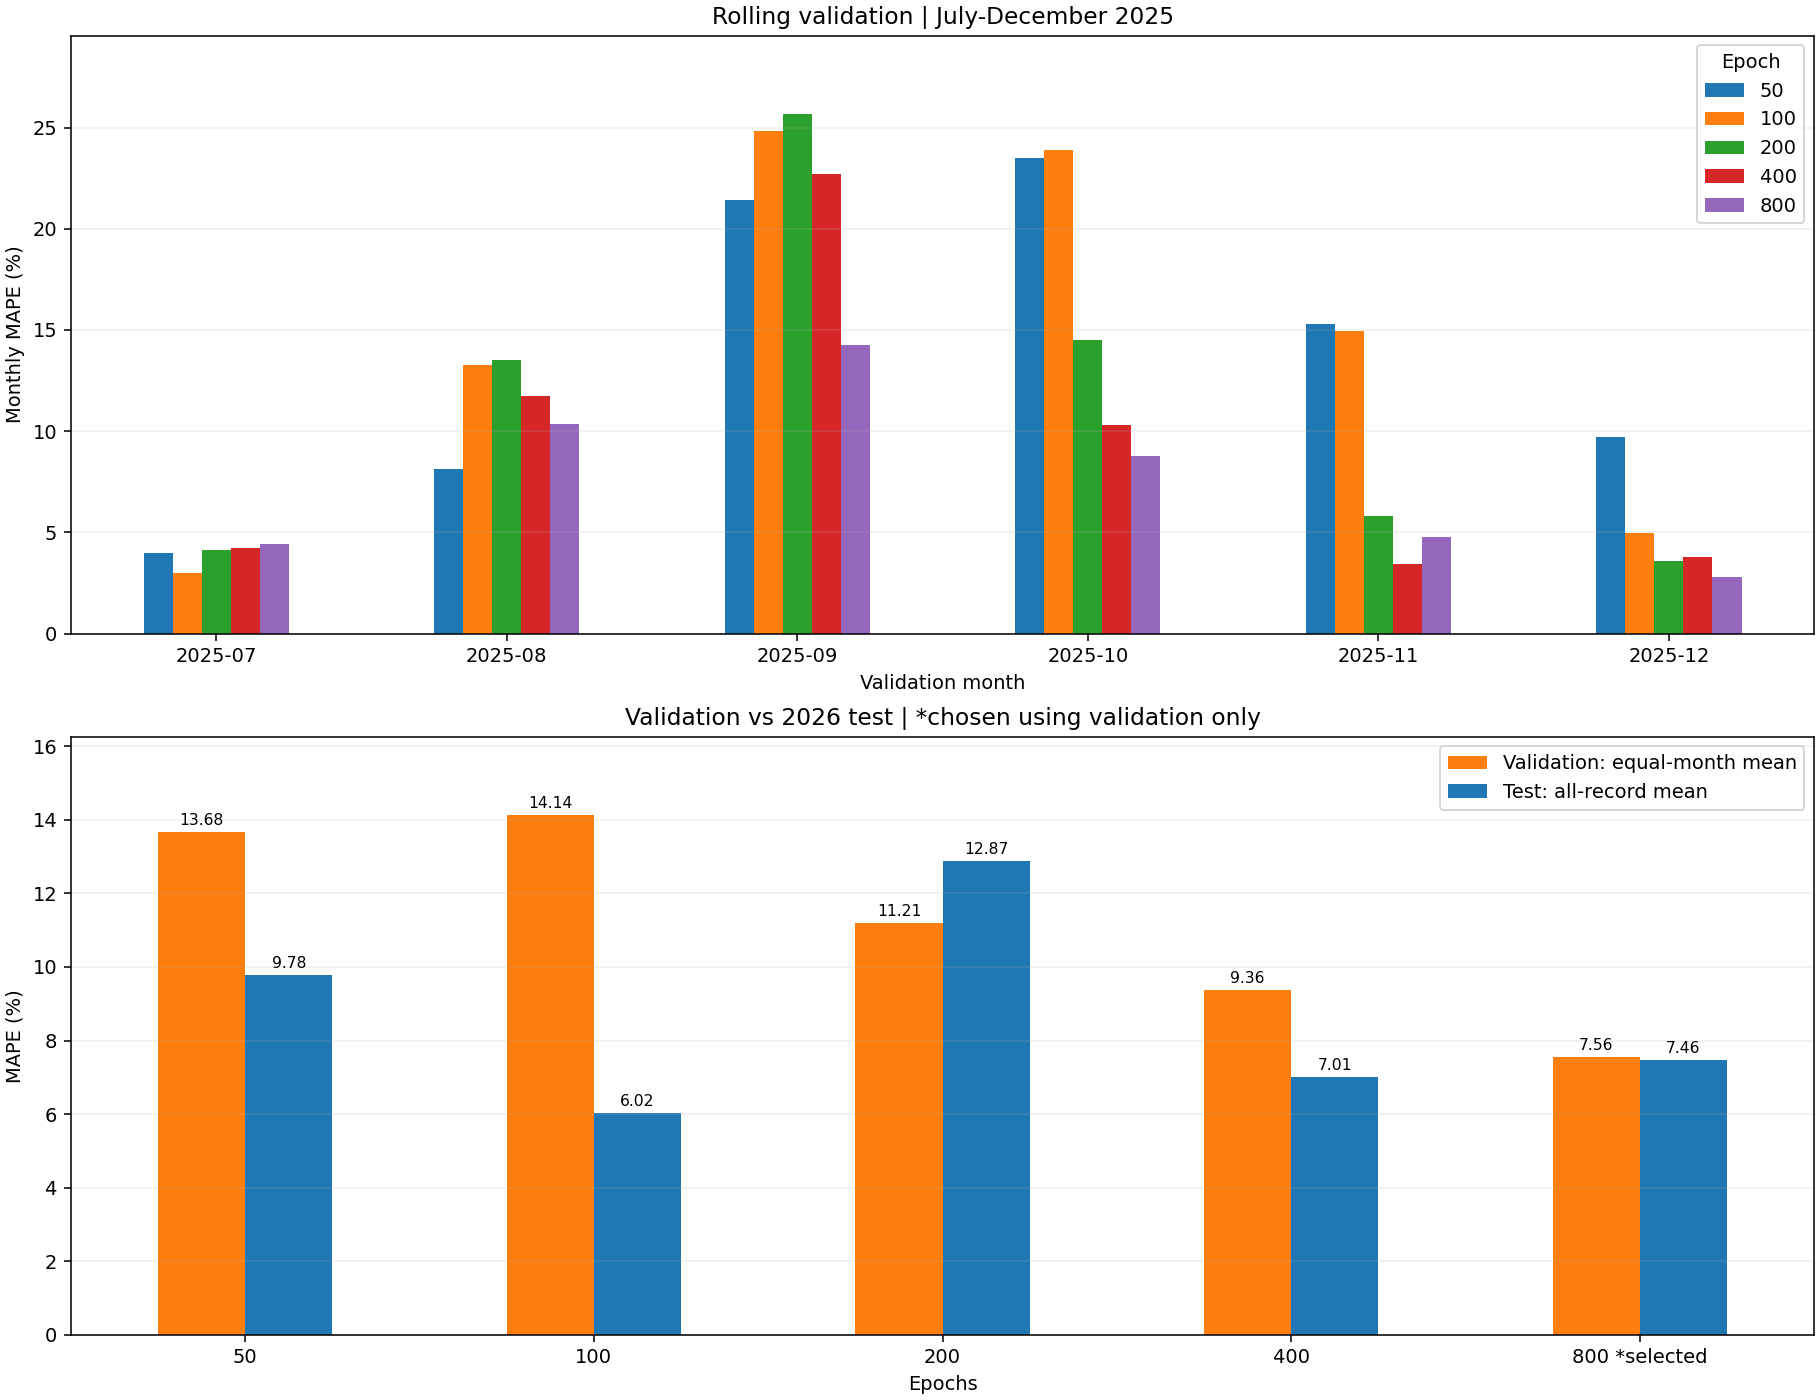

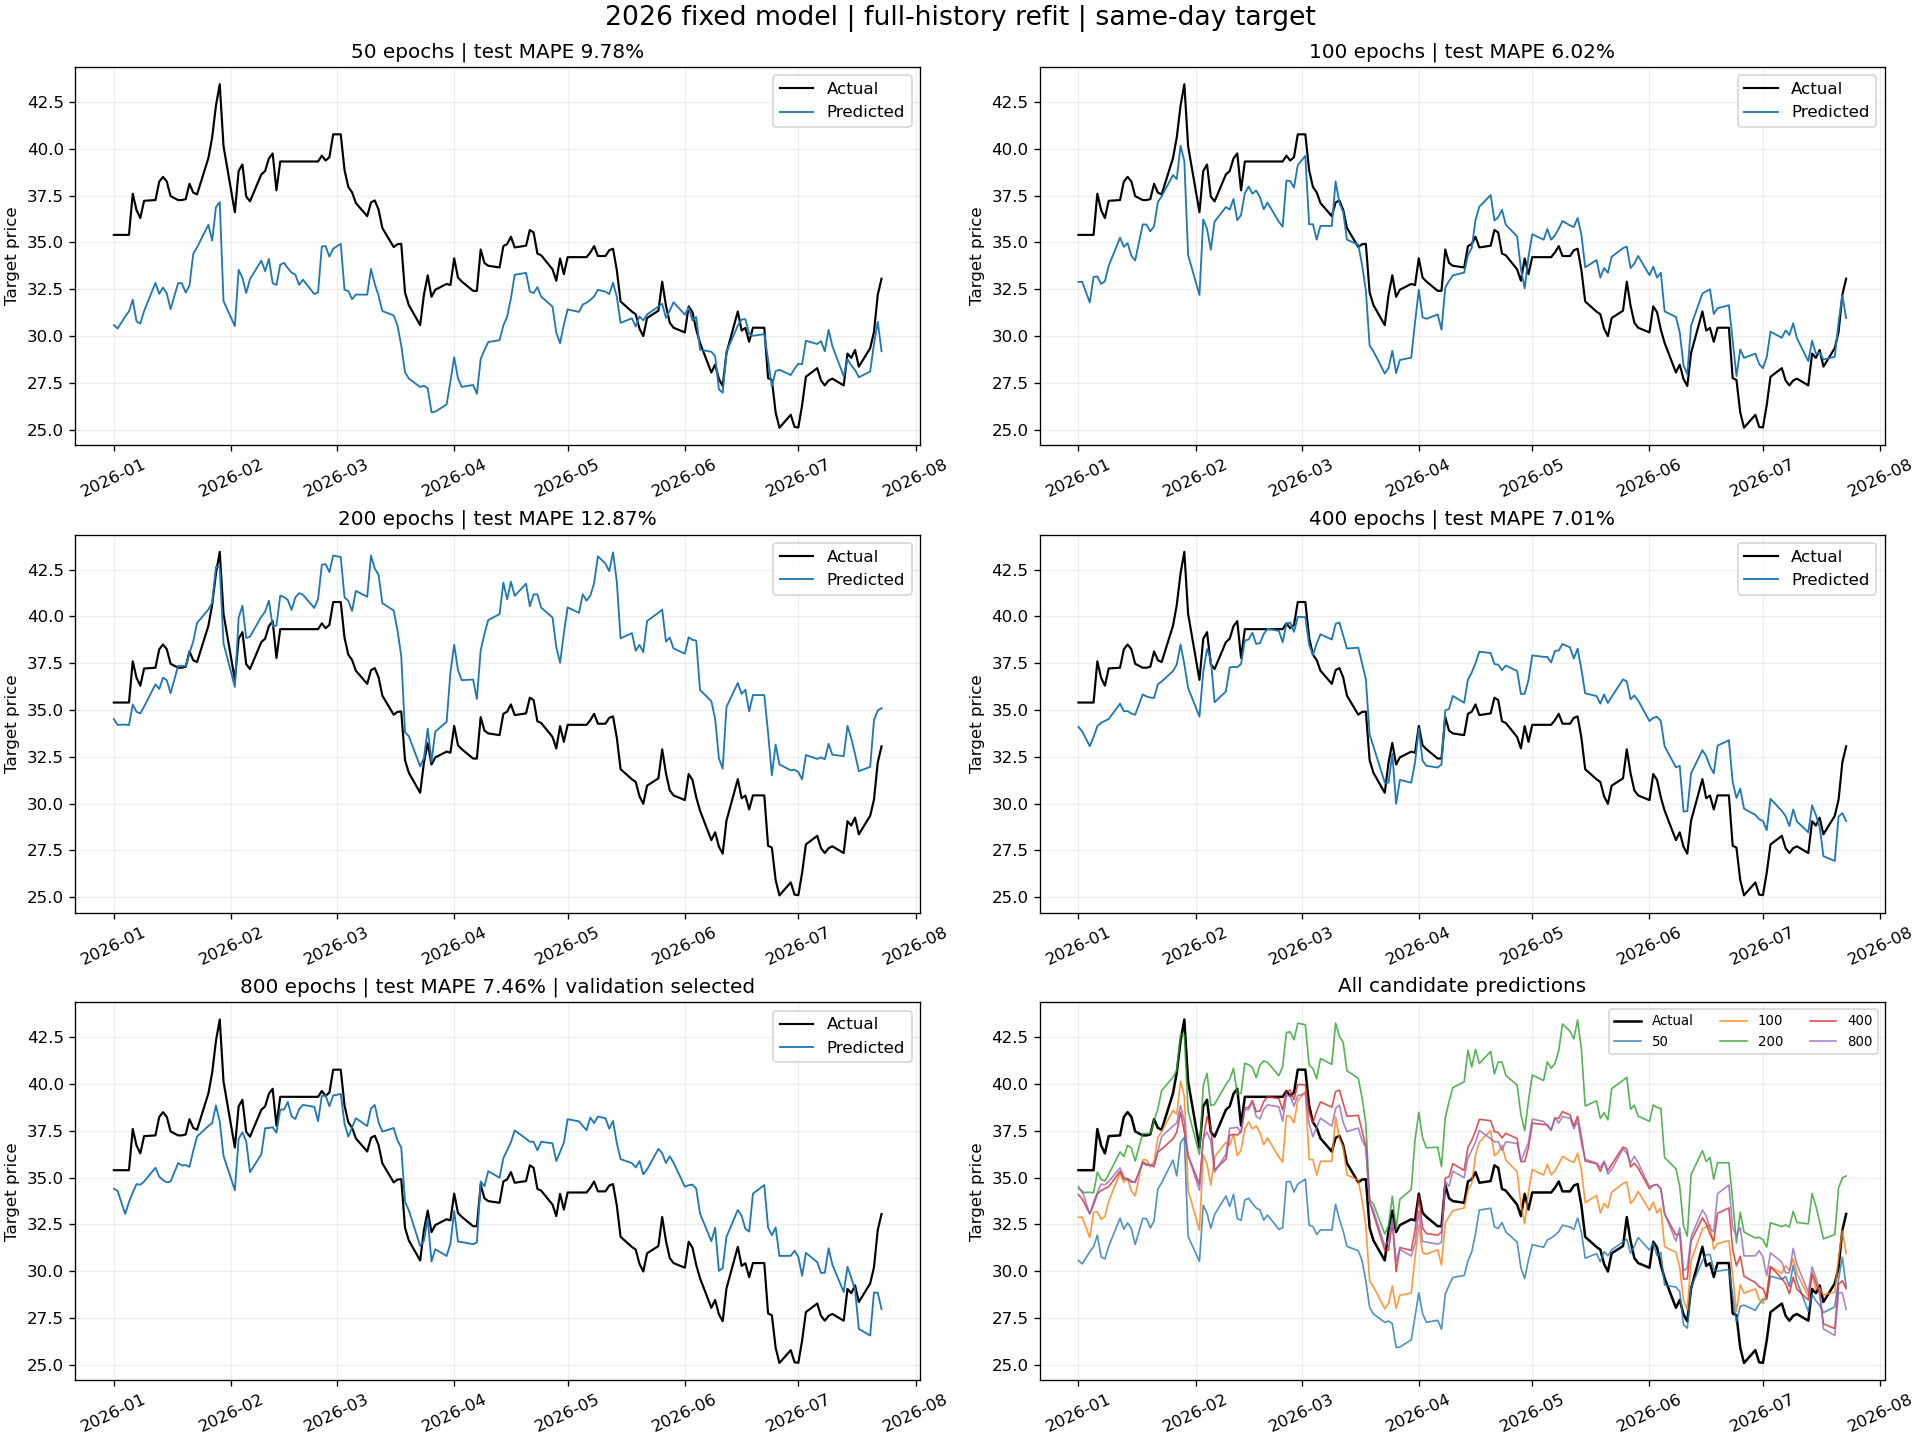

In [ ]:
fig,axes=plt.subplots(2,1,figsize=(13,10),constrained_layout=True)
monthly.drop(columns='Mean_MAPE').T.plot.bar(ax=axes[0],rot=0)
axes[0].set(title='Rolling validation | July-December 2025',ylabel='Monthly MAPE (%)',xlabel='Validation month')
chart=comparison[['Validation_MAPE_equal_month','Test_MAPE_all_records']].copy()
chart.columns=['Validation: equal-month mean','Test: all-record mean']
chart.index=[str(e)+(' *selected' if e==selected_epoch else '') for e in chart.index]
chart.plot.bar(ax=axes[1],rot=0,color=['tab:orange','tab:blue'])
axes[1].set(title='Validation vs 2026 test | *chosen using validation only',ylabel='MAPE (%)',xlabel='Epochs')
for ax in axes:
    ax.grid(axis='y',alpha=.2);ax.margins(y=.15)
    if ax is axes[1]:
        for container in ax.containers:ax.bar_label(container,fmt='%.2f',padding=2,fontsize=8)
fig.savefig(OUT/'validation_test_mape.png',dpi=140);plt.show()
fig,axes=plt.subplots(3,2,figsize=(16,12),constrained_layout=True)
for ax,epoch in zip(axes.flat,CANDIDATES):
    frame=test_predictions[test_predictions.Epoch==epoch]
    ax.plot(frame.Date,frame.Actual,color='black',label='Actual',lw=1.3)
    ax.plot(frame.Date,frame.Predicted,color='tab:blue',label='Predicted',lw=1.1)
    mark=' | validation selected' if epoch==selected_epoch else ''
    ax.set(title=f'{epoch} epochs | test MAPE {comparison.loc[epoch,"Test_MAPE_all_records"]:.2f}%{mark}',ylabel='Target price')
    ax.grid(alpha=.2);ax.legend();ax.tick_params(axis='x',rotation=25)
ax=axes.flat[-1];ax.plot(te,y.loc[te],color='black',label='Actual',lw=1.5)
for epoch in CANDIDATES:
    frame=test_predictions[test_predictions.Epoch==epoch];ax.plot(frame.Date,frame.Predicted,label=str(epoch),lw=1,alpha=.8)
ax.set(title='All candidate predictions',ylabel='Target price');ax.legend(ncol=3,fontsize=8);ax.grid(alpha=.2);ax.tick_params(axis='x',rotation=25)
fig.suptitle('2026 fixed model | full-history refit | same-day target',fontsize=16)
fig.savefig(OUT/'test_predictions_comparison.png',dpi=120);plt.show()


## 本次结果：验证排名没有完整迁移到测试期

候选50/100/200/400/800轮中，2025年7—12月月度等权验证MAPE依次为13.6833%、14.1414%、11.2079%、9.3648%、7.5622%，因此在评价测试误差前选定 **800轮**。

用截至2025年底的全部数据重训后，2026年MAPE依次为9.7793%、6.0224%、12.8715%、7.0076%、7.4608%。验证最优800轮在测试中排第3；验证最后的100轮在测试中最低。400轮在两边都排第2。测试按月等权后排名仍相同，说明不是仅由记录/月度权重口径导致的排名变化。

800轮是本次验证规则选定结果，100轮测试更好属于事后观察，不能倒过来改写验证选择。800又是候选范围上界，当前并未确定全部可能轮数中的验证最优点。

本次不支持“验证MAPE排名必然延续至2026”的假设，也不足以断言滚动验证无用：时期变化、月度验证与全年固定测试的更新方式不同、完整历史重训后的训练动态变化，均可能影响结果。还需在其他历史外层测试年份检查整个选轮流程。已保存六个月的候选权重与完整历史重训权重、逐月MAPE、测试预测曲线与柱状图。

## 追加1000、1500、2000轮：仅比较MAPE柱状图

沿用全模型、ReLU、seed42和相同数据处理。2025年7—12月逐月重新初始化训练，验证MAPE按六个月等权平均；完整2025年底以前历史重训后评价2026，测试MAPE按全部记录平均。只展示三组柱状图，不新增预测曲线。此前已查看测试结果，本轮属于继续探索，不是新的独立测试。

In [ ]:
from pathlib import Path
from copy import deepcopy
import os, json, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from sklearn.preprocessing import StandardScaler
from IPython.display import display
ROOT=next((p for p in [Path.cwd(),*Path.cwd().parents] if (p/'src/pickle/Dataset.pkl').exists()),Path('/Users/admin/数据分析/ZiJin-Mining/ZiJin-Mining-stock-prediction-'))
OUT=Path(os.environ.get('MLP07_MORE_EPOCHS_OUT',str(ROOT/'results/mlp_rolling_more_epochs_07')))
OUT.mkdir(parents=True,exist_ok=True)
SEED,LR,MAIN_EPOCHS,DIAG_EPOCHS=42,.01,100,1000
torch.set_num_threads(1)
d=pd.read_pickle(ROOT/'src/pickle/Dataset.pkl')
x=d['X'].copy(); yy=d['Y'].copy()
assert x.index.equals(yy.index) and x.shape[1]==7
assert isinstance(x.index,pd.DatetimeIndex) and x.index.is_monotonic_increasing and x.index.is_unique
assert np.isfinite(x.to_numpy()).all() and np.isfinite(np.asarray(yy)).all()
y=pd.Series(np.asarray(yy).reshape(-1),index=x.index,name='Actual')
assert (y>0).all()
BASE=list(x.columns)
for metal,col in [('gold','Gold Futures Price'),('copper','Copper Futures Price')]:
    assert (x[col]>0).all()
    for k in [5,20]: x[f'{metal}_{k}']=x[col]/x[col].shift(k)-1
x=x.dropna();y=y.loc[x.index]
EXTRAS={'01_base':[],'02_gold5':['gold_5'],'03_gold20':['gold_20'],
'04_gold5_20':['gold_5','gold_20'],'05_copper5':['copper_5'],'06_copper20':['copper_20'],
'07_copper5_20':['copper_5','copper_20'],'08_both5':['gold_5','copper_5'],
'09_both20':['gold_20','copper_20'],'10_both5_20':['gold_5','gold_20','copper_5','copper_20']}


CANDIDATES=[1000,1500,2000]
MONTHS=pd.date_range('2025-07-01','2025-12-01',freq='MS')
COLS=BASE+['gold_5','gold_20','copper_5','copper_20']
def tensor(a):return torch.tensor(np.asarray(a),dtype=torch.float32)
config={'candidate_epochs':CANDIDATES,'validation_months':[str(t.date()) for t in MONTHS],'features':COLS,'seed':SEED,'lr':LR,
    'test_start':'2026-01-01','dataset_sha256':hashlib.sha256((ROOT/'src/pickle/Dataset.pkl').read_bytes()).hexdigest()}
(OUT/'config.json').write_text(json.dumps(config,ensure_ascii=False,indent=2))

In [ ]:
def train_candidates(train_idx,tag):
    sx=StandardScaler().fit(x.loc[train_idx,COLS])
    sy=StandardScaler().fit(y.loc[train_idx].to_numpy().reshape(-1,1))
    xt=tensor(sx.transform(x.loc[train_idx,COLS]));yt=tensor(sy.transform(y.loc[train_idx].to_numpy().reshape(-1,1)))
    torch.manual_seed(SEED)
    model=nn.Sequential(nn.Linear(len(COLS),16),nn.ReLU(),nn.Linear(16,32),nn.ReLU(),nn.Linear(32,1))
    optimizer=torch.optim.Adam(model.parameters(),lr=LR);states={};losses=[]
    for epoch in range(1,max(CANDIDATES)+1):
        model.train();optimizer.zero_grad();loss=((model(xt)-yt)**2).mean()
        assert torch.isfinite(loss)
        loss.backward();optimizer.step();model.eval()
        with torch.no_grad():mse=((model(xt)-yt)**2).mean().item()
        assert np.isfinite(mse)
        losses.append({'Run':tag,'Epoch':epoch,'Train_MSE':mse})
        if epoch in CANDIDATES:
            states[epoch]=deepcopy(model.state_dict())
            torch.save({'state_dict':states[epoch],'features':COLS,'seed':SEED,'epoch':epoch,
                'train_start':str(train_idx.min()),'train_end':str(train_idx.max()),
                'sx_mean':sx.mean_.tolist(),'sx_scale':sx.scale_.tolist(),'sy_mean':sy.mean_.tolist(),'sy_scale':sy.scale_.tolist()},
                OUT/f'{tag}_epoch{epoch}.pt')
    return model,states,sx,sy,pd.DataFrame(losses)

def predict(model,state,sx,sy,idx):
    model.load_state_dict(state);model.eval()
    with torch.no_grad():pred=sy.inverse_transform(model(tensor(sx.transform(x.loc[idx,COLS]))).numpy()).ravel()
    assert np.isfinite(pred).all()
    return pred

val_rows,val_frames,split_rows,history_frames=[],[],[],[]
for month in MONTHS:
    tr=x.index[x.index<month];end=month+pd.offsets.MonthBegin(1)
    va=x.index[(x.index>=month)&(x.index<end)]
    assert len(tr)>0 and len(va)>0 and tr.max()<va.min()
    tag=month.strftime('%Y-%m')
    split_rows.append({'Month':tag,'Train_start':str(tr.min().date()),'Train_end':str(tr.max().date()),'Train_N':len(tr),
        'Validation_start':str(va.min().date()),'Validation_end':str(va.max().date()),'Validation_N':len(va)})
    model,states,sx,sy,h=train_candidates(tr,tag);history_frames.append(h)
    for epoch in CANDIDATES:
        pred=predict(model,states[epoch],sx,sy,va);truth=y.loc[va].to_numpy();ape=100*np.abs(pred-truth)/truth
        val_rows.append({'Month':tag,'Epoch':epoch,'N':len(va),'MAPE':ape.mean()})
        val_frames.append(pd.DataFrame({'Date':va,'Month':tag,'Epoch':epoch,'Actual':truth,'Predicted':pred,'APE':ape}))
validation=pd.DataFrame(val_rows);validation_predictions=pd.concat(val_frames,ignore_index=True)
monthly=validation.pivot(index='Epoch',columns='Month',values='MAPE').reindex(CANDIDATES)
validation_mean=monthly.mean(axis=1)
selected_epoch=int(validation_mean.idxmin()) # 只基于验证结果，在读取测试误差前固定。
choice={'selected_epoch':selected_epoch,'validation_equal_month_mape':float(validation_mean.loc[selected_epoch]),'rule':'minimum equal-month validation MAPE; tie -> fewer epochs'}
(OUT/'validation_choice.json').write_text(json.dumps(choice,ensure_ascii=False,indent=2))
for key,frame in [('validation_metrics',validation),('validation_predictions',validation_predictions),('validation_splits',pd.DataFrame(split_rows))]:frame.to_csv(OUT/f'{key}.csv',index=False)
monthly['Mean_MAPE']=validation_mean;monthly.to_csv(OUT/'validation_monthly_mape.csv')

In [ ]:
tr=x.index[x.index.year<2026];te=x.index[x.index.year==2026]
assert len(te)>1 and tr.max()<te.min()
model,states,sx,sy,h=train_candidates(tr,'final_to2025');history_frames.append(h)
result_rows,test_frames=[],[]
for epoch in CANDIDATES:
    pred=predict(model,states[epoch],sx,sy,te);truth=y.loc[te].to_numpy()
    frame=pd.DataFrame({'Date':te,'Month':te.strftime('%Y-%m'),'Epoch':epoch,'Actual':truth,'Predicted':pred,'APE':100*np.abs(pred-truth)/truth})
    test_frames.append(frame)
    result_rows.append({'Epoch':epoch,'Validation_MAPE_equal_month':validation_mean.loc[epoch],
        'Test_MAPE_all_records':frame.APE.mean(),'Test_MAPE_equal_month':frame.groupby('Month').APE.mean().mean(),
        'Selected_by_validation':epoch==selected_epoch})
comparison=pd.DataFrame(result_rows).set_index('Epoch')
comparison['Validation_rank']=comparison.Validation_MAPE_equal_month.rank(method='min').astype(int)
comparison['Test_rank']=comparison.Test_MAPE_all_records.rank(method='min').astype(int)
test_predictions=pd.concat(test_frames,ignore_index=True)
test_monthly=test_predictions.groupby(['Epoch','Month']).APE.mean().unstack()
comparison.to_csv(OUT/'validation_test_comparison.csv');test_predictions.to_csv(OUT/'test_predictions.csv',index=False);test_monthly.to_csv(OUT/'test_monthly_mape.csv')
pd.concat(history_frames,ignore_index=True).to_csv(OUT/'training_history.csv',index=False)

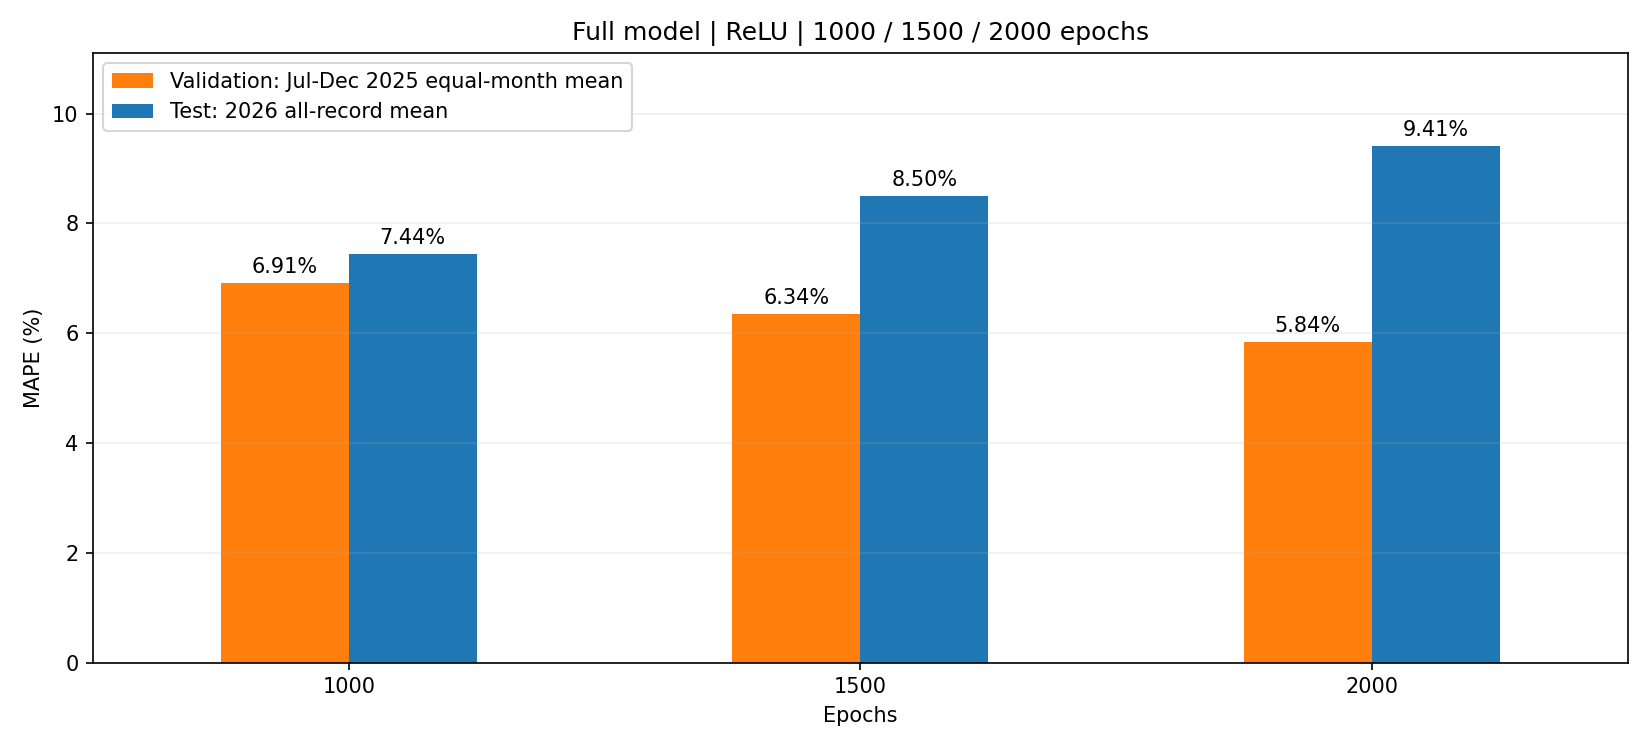

In [ ]:
chart=comparison[['Validation_MAPE_equal_month','Test_MAPE_all_records']].copy()
chart.columns=['Validation: Jul-Dec 2025 equal-month mean','Test: 2026 all-record mean']
chart.index=chart.index.astype(str)
ax=chart.plot.bar(figsize=(11,5),rot=0,color=['tab:orange','tab:blue'])
ax.set(title='Full model | ReLU | 1000 / 1500 / 2000 epochs',xlabel='Epochs',ylabel='MAPE (%)')
for container in ax.containers:ax.bar_label(container,fmt='%.2f%%',padding=3)
ax.margins(y=.18);ax.grid(axis='y',alpha=.2)
plt.tight_layout();plt.savefig(OUT/'validation_test_mape.png',dpi=150);plt.show()


---

经过观察,我们发现,在2026年中,随着训练次数的增多,验证集的偏差虽然变小,但是测试集的偏差却逐步扩大.

我们之后应该重点测试,400,600,800,1000轮,此外针对100轮,由于我们以前测试过,用100轮测试15-25年的效果并不好,因此放弃.

---

# 400、600、800、1000轮：2015—2026逐年测试

在相同全模型上检验“MAPE在这一区间先下降后上升”的假设，不预设曲线形状。固定原7个变量＋金铜各5/20条记录累计涨幅，ReLU、16/32隐藏层、线性输出、Adam学习率0.01、全批量、seed42，无时间。

每个测试年只使用此前全部历史数据训练与拟合缩放器，模型在该测试年内不更新。同年四个轮数沿用同一次初始化和训练路径。这是年度向前测试：本节直接比较四个固定轮数，不再次执行前一年下半年月度选轮，因而不等同于验证整套月度选轮流程。

各年测试MAPE先在该年记录上平均，再对2015—2026的12年等权平均，保留2022。2026仅为现有部分年度，另列2015—2025完整11年平均。所有组统一删除计算涨幅需要的前20条记录；同日目标口径不变。候选范围由已查看结果提出，因此本节仍为探索性检验。

In [1]:
from pathlib import Path
from copy import deepcopy
import os, json, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from sklearn.preprocessing import StandardScaler
from IPython.display import display
ROOT=next((p for p in [Path.cwd(),*Path.cwd().parents] if (p/'src/pickle/Dataset.pkl').exists()),Path('/Users/admin/数据分析/ZiJin-Mining/ZiJin-Mining-stock-prediction-'))
OUT=Path(os.environ.get('MLP08_ANNUAL_OUT',str(ROOT/'results/mlp_epochs_annual_08')))
OUT.mkdir(parents=True,exist_ok=True)
SEED,LR,MAIN_EPOCHS,DIAG_EPOCHS=42,.01,100,1000
torch.set_num_threads(1)
d=pd.read_pickle(ROOT/'src/pickle/Dataset.pkl')
x=d['X'].copy(); yy=d['Y'].copy()
assert x.index.equals(yy.index) and x.shape[1]==7
assert isinstance(x.index,pd.DatetimeIndex) and x.index.is_monotonic_increasing and x.index.is_unique
assert np.isfinite(x.to_numpy()).all() and np.isfinite(np.asarray(yy)).all()
y=pd.Series(np.asarray(yy).reshape(-1),index=x.index,name='Actual')
assert (y>0).all()
BASE=list(x.columns)
for metal,col in [('gold','Gold Futures Price'),('copper','Copper Futures Price')]:
    assert (x[col]>0).all()
    for k in [5,20]: x[f'{metal}_{k}']=x[col]/x[col].shift(k)-1
x=x.dropna();y=y.loc[x.index]
EXTRAS={'01_base':[],'02_gold5':['gold_5'],'03_gold20':['gold_20'],
'04_gold5_20':['gold_5','gold_20'],'05_copper5':['copper_5'],'06_copper20':['copper_20'],
'07_copper5_20':['copper_5','copper_20'],'08_both5':['gold_5','copper_5'],
'09_both20':['gold_20','copper_20'],'10_both5_20':['gold_5','gold_20','copper_5','copper_20']}



CANDIDATES=[400,600,800,1000]
YEARS=list(range(2015,2027))
COLS=BASE+['gold_5','gold_20','copper_5','copper_20']
def tensor(a):return torch.tensor(np.asarray(a),dtype=torch.float32)
config={'epochs':CANDIDATES,'years':YEARS,'features':COLS,'seed':SEED,'lr':LR,'test_mode':'fixed model within each test year',
'dataset_sha256':hashlib.sha256((ROOT/'src/pickle/Dataset.pkl').read_bytes()).hexdigest()}
(OUT/'config.json').write_text(json.dumps(config,ensure_ascii=False,indent=2))


Out[1]: 582


In [2]:
def train_candidates(train_idx,tag):
    sx=StandardScaler().fit(x.loc[train_idx,COLS])
    sy=StandardScaler().fit(y.loc[train_idx].to_numpy().reshape(-1,1))
    xt=tensor(sx.transform(x.loc[train_idx,COLS]));yt=tensor(sy.transform(y.loc[train_idx].to_numpy().reshape(-1,1)))
    torch.manual_seed(SEED)
    model=nn.Sequential(nn.Linear(len(COLS),16),nn.ReLU(),nn.Linear(16,32),nn.ReLU(),nn.Linear(32,1))
    optimizer=torch.optim.Adam(model.parameters(),lr=LR);states={};losses=[]
    for epoch in range(1,max(CANDIDATES)+1):
        model.train();optimizer.zero_grad();loss=((model(xt)-yt)**2).mean()
        assert torch.isfinite(loss)
        loss.backward();optimizer.step();model.eval()
        with torch.no_grad():mse=((model(xt)-yt)**2).mean().item()
        assert np.isfinite(mse)
        losses.append({'Run':tag,'Epoch':epoch,'Train_MSE':mse})
        if epoch in CANDIDATES:
            states[epoch]=deepcopy(model.state_dict())
            torch.save({'state_dict':states[epoch],'features':COLS,'seed':SEED,'epoch':epoch,
                'train_start':str(train_idx.min()),'train_end':str(train_idx.max()),
                'sx_mean':sx.mean_.tolist(),'sx_scale':sx.scale_.tolist(),'sy_mean':sy.mean_.tolist(),'sy_scale':sy.scale_.tolist()},
                OUT/f'{tag}_epoch{epoch}.pt')
    return model,states,sx,sy,pd.DataFrame(losses)

def predict(model,state,sx,sy,idx):
    model.load_state_dict(state);model.eval()
    with torch.no_grad():pred=sy.inverse_transform(model(tensor(sx.transform(x.loc[idx,COLS]))).numpy()).ravel()
    assert np.isfinite(pred).all()
    return pred


rows,pred_frames,history_frames,split_rows=[],[],[],[]
for year in YEARS:
    tr=x.index[x.index.year<year];te=x.index[x.index.year==year]
    assert len(tr)>0 and len(te)>1 and tr.max()<te.min()
    model,states,sx,sy,h=train_candidates(tr,str(year));history_frames.append(h)
    for split,idx in [('Train',tr),('Test',te)]:
        split_rows.append({'Year':year,'Split':split,'N':len(idx),'Start':str(idx.min().date()),'End':str(idx.max().date())})
        for epoch in CANDIDATES:
            pred=predict(model,states[epoch],sx,sy,idx);truth=y.loc[idx].to_numpy();pe=100*(pred-truth)/truth
            rows.append({'Year':year,'Epoch':epoch,'Split':split,'N':len(idx),'MAPE':np.abs(pe).mean(),'MPE':pe.mean()})
            pred_frames.append(pd.DataFrame({'Date':idx,'Year':year,'Epoch':epoch,'Split':split,'Actual':truth,'Predicted':pred,'APE':np.abs(pe)}))
    print(year,'完成',flush=True)
metrics=pd.DataFrame(rows);predictions=pd.concat(pred_frames,ignore_index=True);history=pd.concat(history_frames,ignore_index=True)
splits=pd.DataFrame(split_rows)
for key,df in [('metrics',metrics),('predictions',predictions),('training_history',history),('splits',splits)]:df.to_csv(OUT/f'{key}.csv',index=False)
display(splits[splits.Split=='Test'])
annual=metrics[metrics.Split=='Test'].pivot(index='Year',columns='Epoch',values='MAPE')[CANDIDATES]
means=pd.DataFrame({'Mean_2015_2026':annual.mean(),'Mean_2015_2025':annual.loc[2015:2025].mean()}).T
annual.to_csv(OUT/'annual_test_mape.csv');means.to_csv(OUT/'mean_test_mape.csv')
display(annual.round(4));display(means.round(4))
# 四个采样点的严格先降后升：最低点须在600或800，前段逐项下降，后段逐项上升。
def falls_then_rises(values):
    v=np.asarray(values,dtype=float);j=int(np.argmin(v))
    return bool(0<j<len(v)-1 and np.all(np.diff(v[:j+1])<0) and np.all(np.diff(v[j:])>0))
shape=pd.DataFrame({'Best_candidate':annual.idxmin(axis=1),'Falls_then_rises':annual.apply(falls_then_rises,axis=1)})
shape.to_csv(OUT/'curve_shape_diagnostics.csv');display(shape)
print('12年平均最低候选：',int(means.loc['Mean_2015_2026'].idxmin()))
print('12年平均是否先降后升：',falls_then_rises(means.loc['Mean_2015_2026']))
print('各年符合四点严格先降后升的数量：',int(shape.Falls_then_rises.sum()),'/12')


2015 完成
2016 完成
2017 完成
2018 完成
2019 完成
2020 完成
2021 完成
2022 完成
2023 完成
2024 完成
2025 完成
2026 完成
12年平均最低候选： 400
12年平均是否先降后升： False
各年符合四点严格先降后升的数量： 0 /12


,Year,Split,N,Start,End
1,2015,Test,266,2015-01-01,2015-12-31
3,2016,Test,268,2016-01-01,2016-12-31
5,2017,Test,267,2017-01-02,2017-12-31
7,2018,Test,269,2018-01-01,2018-12-31
9,2019,Test,271,2019-01-01,2019-12-31
11,2020,Test,271,2020-01-01,2020-12-31
13,2021,Test,272,2021-01-01,2021-12-31
15,2022,Test,274,2022-01-03,2022-12-31
17,2023,Test,273,2023-01-02,2023-12-31
19,2024,Test,273,2024-01-01,2024-12-31


Epoch,400,600,800,1000
Year,,,,
2015,10.2953,10.5865,12.4610,14.7040
2016,8.5732,8.7303,8.3413,8.3580
2017,14.2060,15.2539,15.9039,16.6743
2018,8.1917,8.4444,9.1202,9.0811
2019,8.6385,8.8157,8.3702,8.6431
2020,24.7115,29.8914,32.2077,33.7952
2021,8.4667,12.9759,14.9114,19.2250
2022,35.3859,39.3879,41.3788,40.2297
2023,9.5988,10.0597,10.2675,10.4138


Epoch,400,600,800,1000
Mean_2015_2026,13.1554,14.4128,15.1984,15.8653
Mean_2015_2025,13.7143,15.1242,15.9018,16.6308


,Best_candidate,Falls_then_rises
Year,,
2015,400,False
2016,800,False
2017,400,False
2018,400,False
2019,800,False
2020,400,False
2021,400,False
2022,400,False
2023,400,False


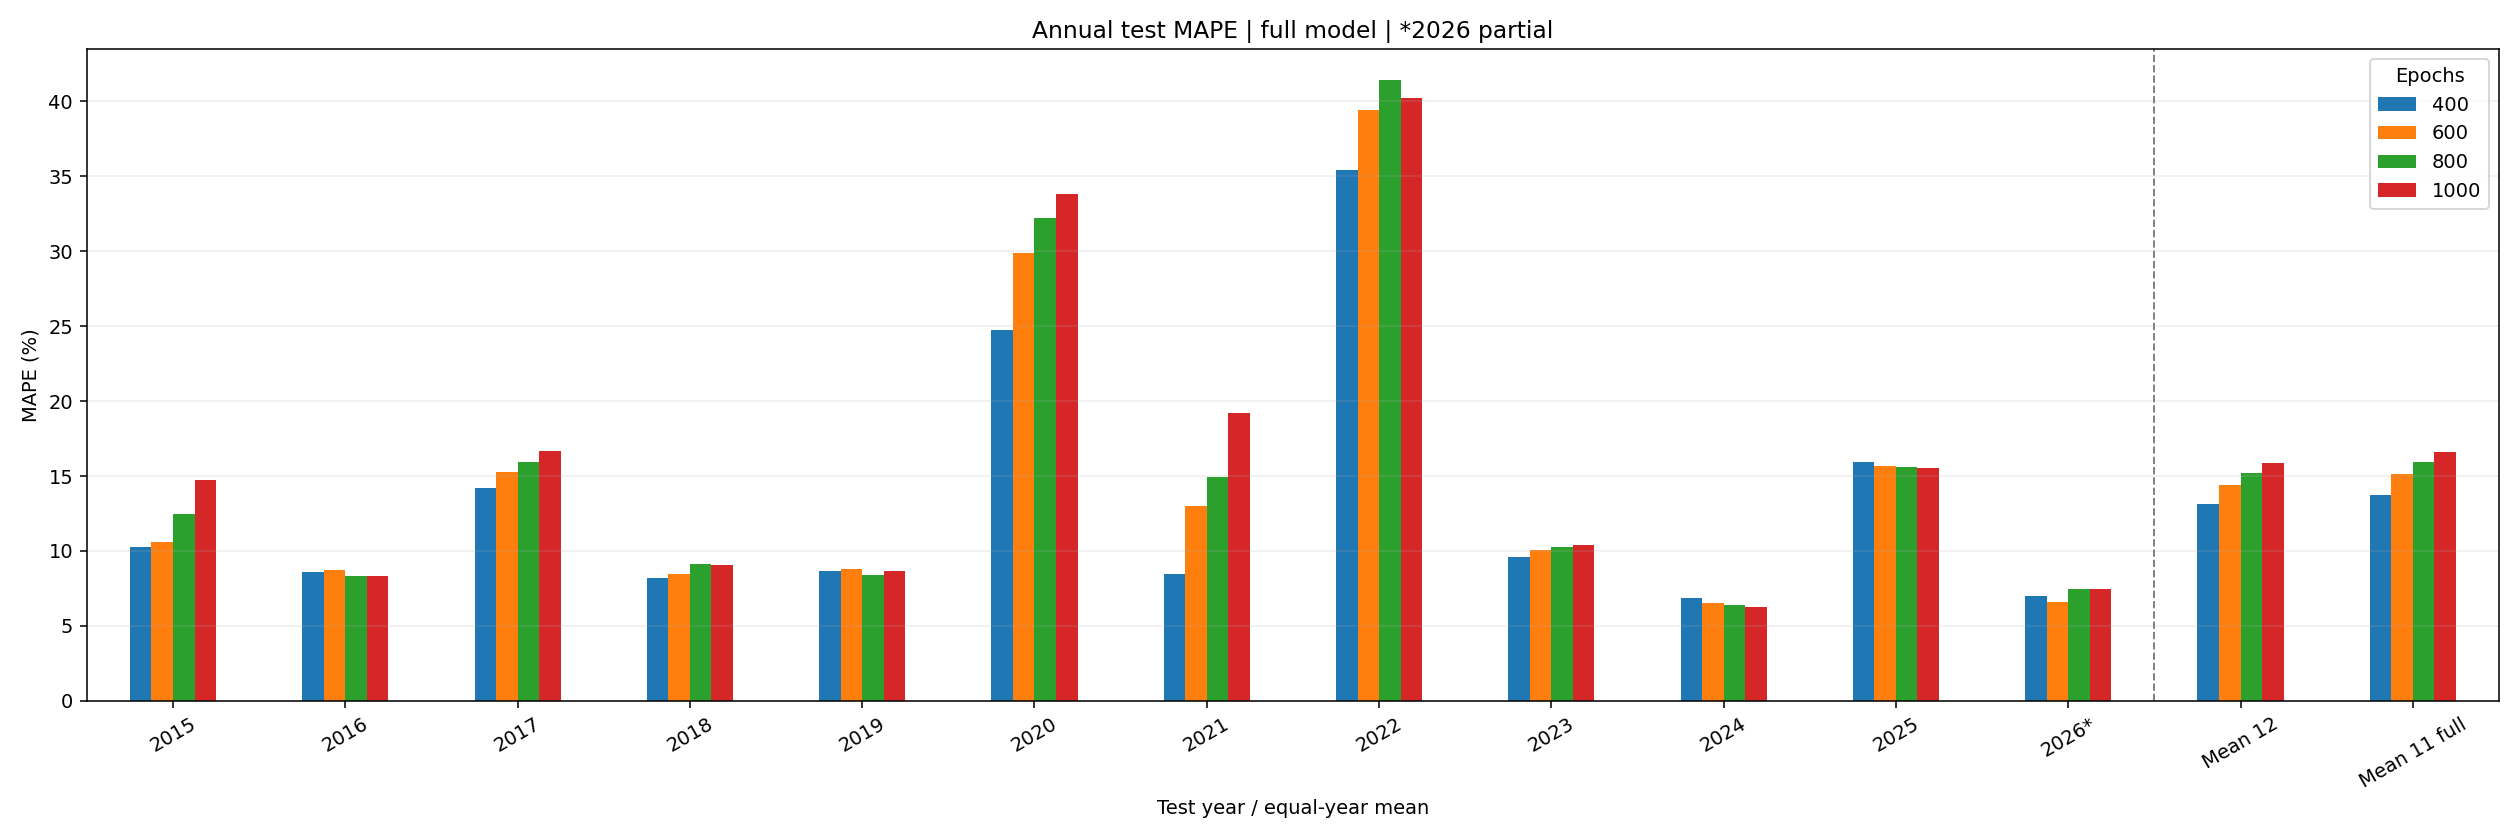

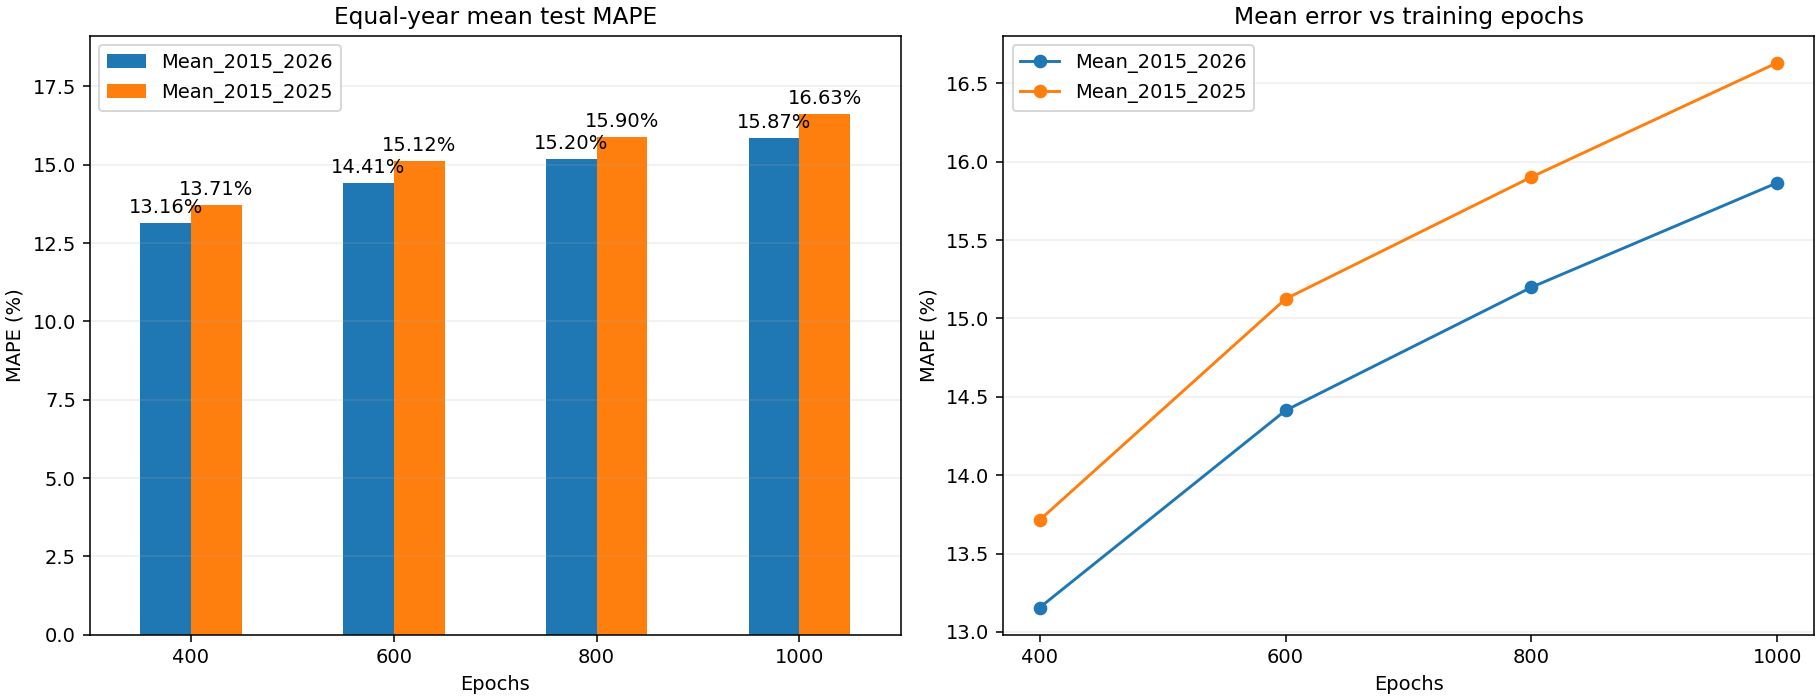

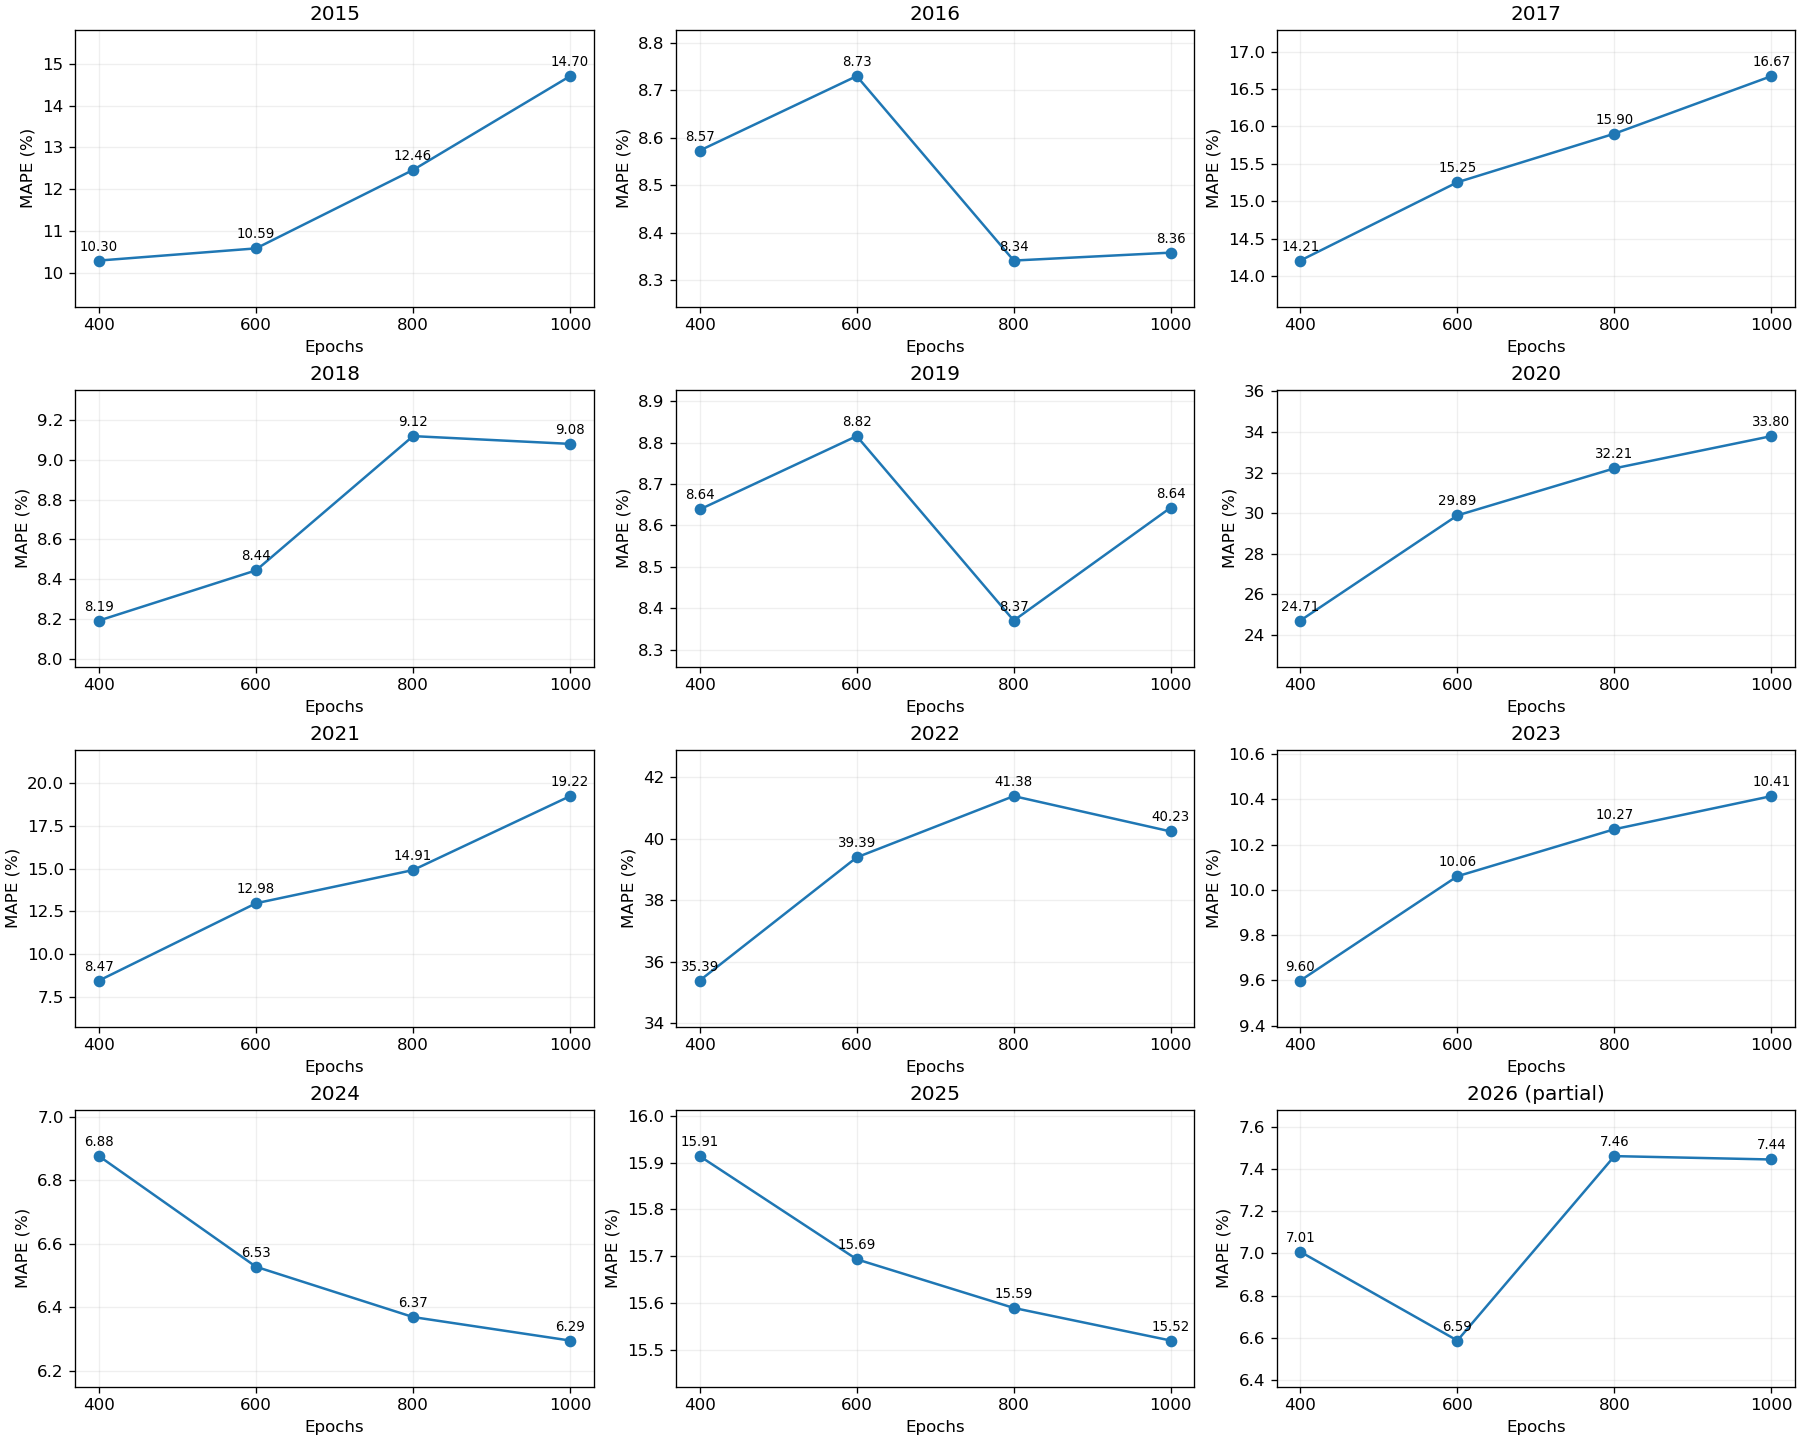

In [3]:
chart=annual.copy();chart.index=[str(y)+('*' if y==2026 else '') for y in chart.index]
chart.loc['Mean 12']=means.loc['Mean_2015_2026'];chart.loc['Mean 11 full']=means.loc['Mean_2015_2025']
ax=chart.plot.bar(figsize=(18,6),rot=30)
ax.set(title='Annual test MAPE | full model | *2026 partial',xlabel='Test year / equal-year mean',ylabel='MAPE (%)')
ax.axvline(11.5,color='gray',ls='--',lw=1);ax.grid(axis='y',alpha=.2)
ax.legend(title='Epochs');plt.tight_layout();plt.savefig(OUT/'annual_mape_bar.png',dpi=140);plt.show()
fig,axes=plt.subplots(1,2,figsize=(13,5),constrained_layout=True)
means.T.plot.bar(ax=axes[0],rot=0,color=['tab:blue','tab:orange'])
for container in axes[0].containers:axes[0].bar_label(container,fmt='%.2f%%',padding=3)
axes[0].set(title='Equal-year mean test MAPE',xlabel='Epochs',ylabel='MAPE (%)');axes[0].margins(y=.15)
for name,row in means.iterrows():axes[1].plot(CANDIDATES,row.to_numpy(),marker='o',label=name)
axes[1].set(title='Mean error vs training epochs',xlabel='Epochs',ylabel='MAPE (%)',xticks=CANDIDATES)
axes[1].legend()
for ax in axes:ax.grid(axis='y',alpha=.2)
fig.savefig(OUT/'mean_mape_curve.png',dpi=140);plt.show()
fig,axes=plt.subplots(4,3,figsize=(15,12),constrained_layout=True)
for ax,year in zip(axes.flat,YEARS):
    vals=annual.loc[year];ax.plot(CANDIDATES,vals,marker='o')
    for epoch,value in vals.items():ax.annotate(f'{value:.2f}',(epoch,value),xytext=(0,6),textcoords='offset points',ha='center',fontsize=8)
    ax.set(title=str(year)+(' (partial)' if year==2026 else ''),xlabel='Epochs',ylabel='MAPE (%)',xticks=CANDIDATES)
    ax.margins(y=.25);ax.grid(alpha=.2)
fig.savefig(OUT/'annual_mape_curves.png',dpi=120);plt.show()


## 本次结论

400/600/800/1000轮的2015—2026年度等权平均MAPE依次为 **13.1554%、14.4128%、15.1984%、15.8653%**，在这四个采样点上持续上升，不支持整体存在先降后升。完整2015—2025均值为13.7143%、15.1242%、15.9018%、16.6308%，方向一致。

四个候选中，400轮在7/12年最低，800轮在2016、2019两年最低，1000轮在2024、2025两年最低，600轮在2026最低。2026分别为7.0076%、6.5872%、7.4608%、7.4448%，呈现600轮局部低点，但不是严格单调下降后单调上升（800至1000略降），也不代表所有年份具有同样形状。

因此，本次只支持400轮是这四个候选的年度平均最优，不能认定400—1000是全局最佳范围。此前相同全模型100轮的12年均值为12.2155%，仍低于本次400轮均值13.1554%；不能因为只测试这四个轮数而排除区间外可能更好的选择。

本节测试的是固定候选的年度表现，没有逐年执行前一年下半年按月选轮，因而不单独验证滚动验证选轮方法是否有效。结果为seed42，保留全部年份，2026截至7月23日；候选范围来自已查看数据，属于探索性证据。

---

这两个实验有些问题.  
上一个实验是测试25年的下半年滚动测试,选取验证集最小的,也就是说加深训练次数,验证集效果提升,但是对于测试集来说并不好.  
这一次是根据26年的经验,指定了几个训练轮数,总体而言,训练次数的增加反而让效果更差,今年随着训练次数增加,但是下降幅度并不明显.因此,经验上来看,我们再比较100,200,300,400轮.

---

# 100、200、300、400轮：相同全模型逐年对照

沿用原7个水平变量＋金铜各5/20条记录累计涨幅，共11输入，无时间；ReLU、16/32、线性输出、Adam学习率0.01、全批量、seed42。同年各候选来自相同初始化和训练路径，固定保存对应轮数权重。

2015—2026逐年测试，每次只用测试年前全部共同样本训练及拟合标准化器，测试年内不更新。各年MAPE按记录平均，再对年份等权平均；包含2022，2026为部分年度，另列完整2015—2025均值。与上一节完全相同口径，只修改候选轮数。

这次检验固定轮数的历史表现，不重新进行前一年下半年滚动选轮。候选来自已查看结果，属于探索性比较。

In [1]:
from pathlib import Path
from copy import deepcopy
import os, json, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from sklearn.preprocessing import StandardScaler
from IPython.display import display
ROOT=next((p for p in [Path.cwd(),*Path.cwd().parents] if (p/'src/pickle/Dataset.pkl').exists()),Path('/Users/admin/数据分析/ZiJin-Mining/ZiJin-Mining-stock-prediction-'))
OUT=Path(os.environ.get('MLP08_LOW_EPOCHS_OUT',str(ROOT/'results/mlp_epochs100_400_annual_08')))
OUT.mkdir(parents=True,exist_ok=True)
SEED,LR,MAIN_EPOCHS,DIAG_EPOCHS=42,.01,100,1000
torch.set_num_threads(1)
d=pd.read_pickle(ROOT/'src/pickle/Dataset.pkl')
x=d['X'].copy(); yy=d['Y'].copy()
assert x.index.equals(yy.index) and x.shape[1]==7
assert isinstance(x.index,pd.DatetimeIndex) and x.index.is_monotonic_increasing and x.index.is_unique
assert np.isfinite(x.to_numpy()).all() and np.isfinite(np.asarray(yy)).all()
y=pd.Series(np.asarray(yy).reshape(-1),index=x.index,name='Actual')
assert (y>0).all()
BASE=list(x.columns)
for metal,col in [('gold','Gold Futures Price'),('copper','Copper Futures Price')]:
    assert (x[col]>0).all()
    for k in [5,20]: x[f'{metal}_{k}']=x[col]/x[col].shift(k)-1
x=x.dropna();y=y.loc[x.index]
EXTRAS={'01_base':[],'02_gold5':['gold_5'],'03_gold20':['gold_20'],
'04_gold5_20':['gold_5','gold_20'],'05_copper5':['copper_5'],'06_copper20':['copper_20'],
'07_copper5_20':['copper_5','copper_20'],'08_both5':['gold_5','copper_5'],
'09_both20':['gold_20','copper_20'],'10_both5_20':['gold_5','gold_20','copper_5','copper_20']}



CANDIDATES=[100,200,300,400]
YEARS=list(range(2015,2027))
COLS=BASE+['gold_5','gold_20','copper_5','copper_20']
def tensor(a):return torch.tensor(np.asarray(a),dtype=torch.float32)
config={'epochs':CANDIDATES,'years':YEARS,'features':COLS,'seed':SEED,'lr':LR,'test_mode':'fixed model within each test year',
'dataset_sha256':hashlib.sha256((ROOT/'src/pickle/Dataset.pkl').read_bytes()).hexdigest()}
(OUT/'config.json').write_text(json.dumps(config,ensure_ascii=False,indent=2))


Out[1]: 581


In [2]:
def train_candidates(train_idx,tag):
    sx=StandardScaler().fit(x.loc[train_idx,COLS])
    sy=StandardScaler().fit(y.loc[train_idx].to_numpy().reshape(-1,1))
    xt=tensor(sx.transform(x.loc[train_idx,COLS]));yt=tensor(sy.transform(y.loc[train_idx].to_numpy().reshape(-1,1)))
    torch.manual_seed(SEED)
    model=nn.Sequential(nn.Linear(len(COLS),16),nn.ReLU(),nn.Linear(16,32),nn.ReLU(),nn.Linear(32,1))
    optimizer=torch.optim.Adam(model.parameters(),lr=LR);states={};losses=[]
    for epoch in range(1,max(CANDIDATES)+1):
        model.train();optimizer.zero_grad();loss=((model(xt)-yt)**2).mean()
        assert torch.isfinite(loss)
        loss.backward();optimizer.step();model.eval()
        with torch.no_grad():mse=((model(xt)-yt)**2).mean().item()
        assert np.isfinite(mse)
        losses.append({'Run':tag,'Epoch':epoch,'Train_MSE':mse})
        if epoch in CANDIDATES:
            states[epoch]=deepcopy(model.state_dict())
            torch.save({'state_dict':states[epoch],'features':COLS,'seed':SEED,'epoch':epoch,
                'train_start':str(train_idx.min()),'train_end':str(train_idx.max()),
                'sx_mean':sx.mean_.tolist(),'sx_scale':sx.scale_.tolist(),'sy_mean':sy.mean_.tolist(),'sy_scale':sy.scale_.tolist()},
                OUT/f'{tag}_epoch{epoch}.pt')
    return model,states,sx,sy,pd.DataFrame(losses)

def predict(model,state,sx,sy,idx):
    model.load_state_dict(state);model.eval()
    with torch.no_grad():pred=sy.inverse_transform(model(tensor(sx.transform(x.loc[idx,COLS]))).numpy()).ravel()
    assert np.isfinite(pred).all()
    return pred


rows,pred_frames,history_frames,split_rows=[],[],[],[]
for year in YEARS:
    tr=x.index[x.index.year<year];te=x.index[x.index.year==year]
    assert len(tr)>0 and len(te)>1 and tr.max()<te.min()
    model,states,sx,sy,h=train_candidates(tr,str(year));history_frames.append(h)
    for split,idx in [('Train',tr),('Test',te)]:
        split_rows.append({'Year':year,'Split':split,'N':len(idx),'Start':str(idx.min().date()),'End':str(idx.max().date())})
        for epoch in CANDIDATES:
            pred=predict(model,states[epoch],sx,sy,idx);truth=y.loc[idx].to_numpy();pe=100*(pred-truth)/truth
            rows.append({'Year':year,'Epoch':epoch,'Split':split,'N':len(idx),'MAPE':np.abs(pe).mean(),'MPE':pe.mean()})
            pred_frames.append(pd.DataFrame({'Date':idx,'Year':year,'Epoch':epoch,'Split':split,'Actual':truth,'Predicted':pred,'APE':np.abs(pe)}))
    print(year,'完成',flush=True)
metrics=pd.DataFrame(rows);predictions=pd.concat(pred_frames,ignore_index=True);history=pd.concat(history_frames,ignore_index=True)
splits=pd.DataFrame(split_rows)
for key,df in [('metrics',metrics),('predictions',predictions),('training_history',history),('splits',splits)]:df.to_csv(OUT/f'{key}.csv',index=False)
display(splits[splits.Split=='Test'])
annual=metrics[metrics.Split=='Test'].pivot(index='Year',columns='Epoch',values='MAPE')[CANDIDATES]
means=pd.DataFrame({'Mean_2015_2026':annual.mean(),'Mean_2015_2025':annual.loc[2015:2025].mean()}).T
annual.to_csv(OUT/'annual_test_mape.csv');means.to_csv(OUT/'mean_test_mape.csv')
display(annual.round(4));display(means.round(4))
# 四个采样点的严格先降后升：最低点须在200或300，前段逐项下降，后段逐项上升。
def falls_then_rises(values):
    v=np.asarray(values,dtype=float);j=int(np.argmin(v))
    return bool(0<j<len(v)-1 and np.all(np.diff(v[:j+1])<0) and np.all(np.diff(v[j:])>0))
shape=pd.DataFrame({'Best_candidate':annual.idxmin(axis=1),'Falls_then_rises':annual.apply(falls_then_rises,axis=1)})
shape.to_csv(OUT/'curve_shape_diagnostics.csv');display(shape)
print('12年平均最低候选：',int(means.loc['Mean_2015_2026'].idxmin()))
print('12年平均是否先降后升：',falls_then_rises(means.loc['Mean_2015_2026']))
print('各年符合四点严格先降后升的数量：',int(shape.Falls_then_rises.sum()),'/12')


2015 完成
2016 完成
2017 完成
2018 完成
2019 完成
2020 完成
2021 完成
2022 完成
2023 完成
2024 完成
2025 完成
2026 完成
12年平均最低候选： 100
12年平均是否先降后升： False
各年符合四点严格先降后升的数量： 4 /12


,Year,Split,N,Start,End
1,2015,Test,266,2015-01-01,2015-12-31
3,2016,Test,268,2016-01-01,2016-12-31
5,2017,Test,267,2017-01-02,2017-12-31
7,2018,Test,269,2018-01-01,2018-12-31
9,2019,Test,271,2019-01-01,2019-12-31
11,2020,Test,271,2020-01-01,2020-12-31
13,2021,Test,272,2021-01-01,2021-12-31
15,2022,Test,274,2022-01-03,2022-12-31
17,2023,Test,273,2023-01-02,2023-12-31
19,2024,Test,273,2024-01-01,2024-12-31


Epoch,100,200,300,400
Year,,,,
2015,9.7961,10.8475,10.8508,10.2953
2016,7.0006,7.8254,8.6323,8.5732
2017,14.4632,12.9133,13.2899,14.2060
2018,7.5655,6.8410,7.5099,8.1917
2019,7.6198,7.4321,8.5255,8.6385
2020,15.6667,19.6736,22.5728,24.7115
2021,6.9679,7.2448,7.6690,8.4667
2022,31.9622,34.9867,34.9532,35.3859
2023,13.0325,10.8872,9.5578,9.5988


Epoch,100,200,300,400
Mean_2015_2026,12.2155,12.9996,13.1745,13.1554
Mean_2015_2025,12.7785,13.0113,13.3634,13.7143


,Best_candidate,Falls_then_rises
Year,,
2015,100,False
2016,100,False
2017,200,True
2018,200,True
2019,200,True
2020,100,False
2021,100,False
2022,100,False
2023,300,True


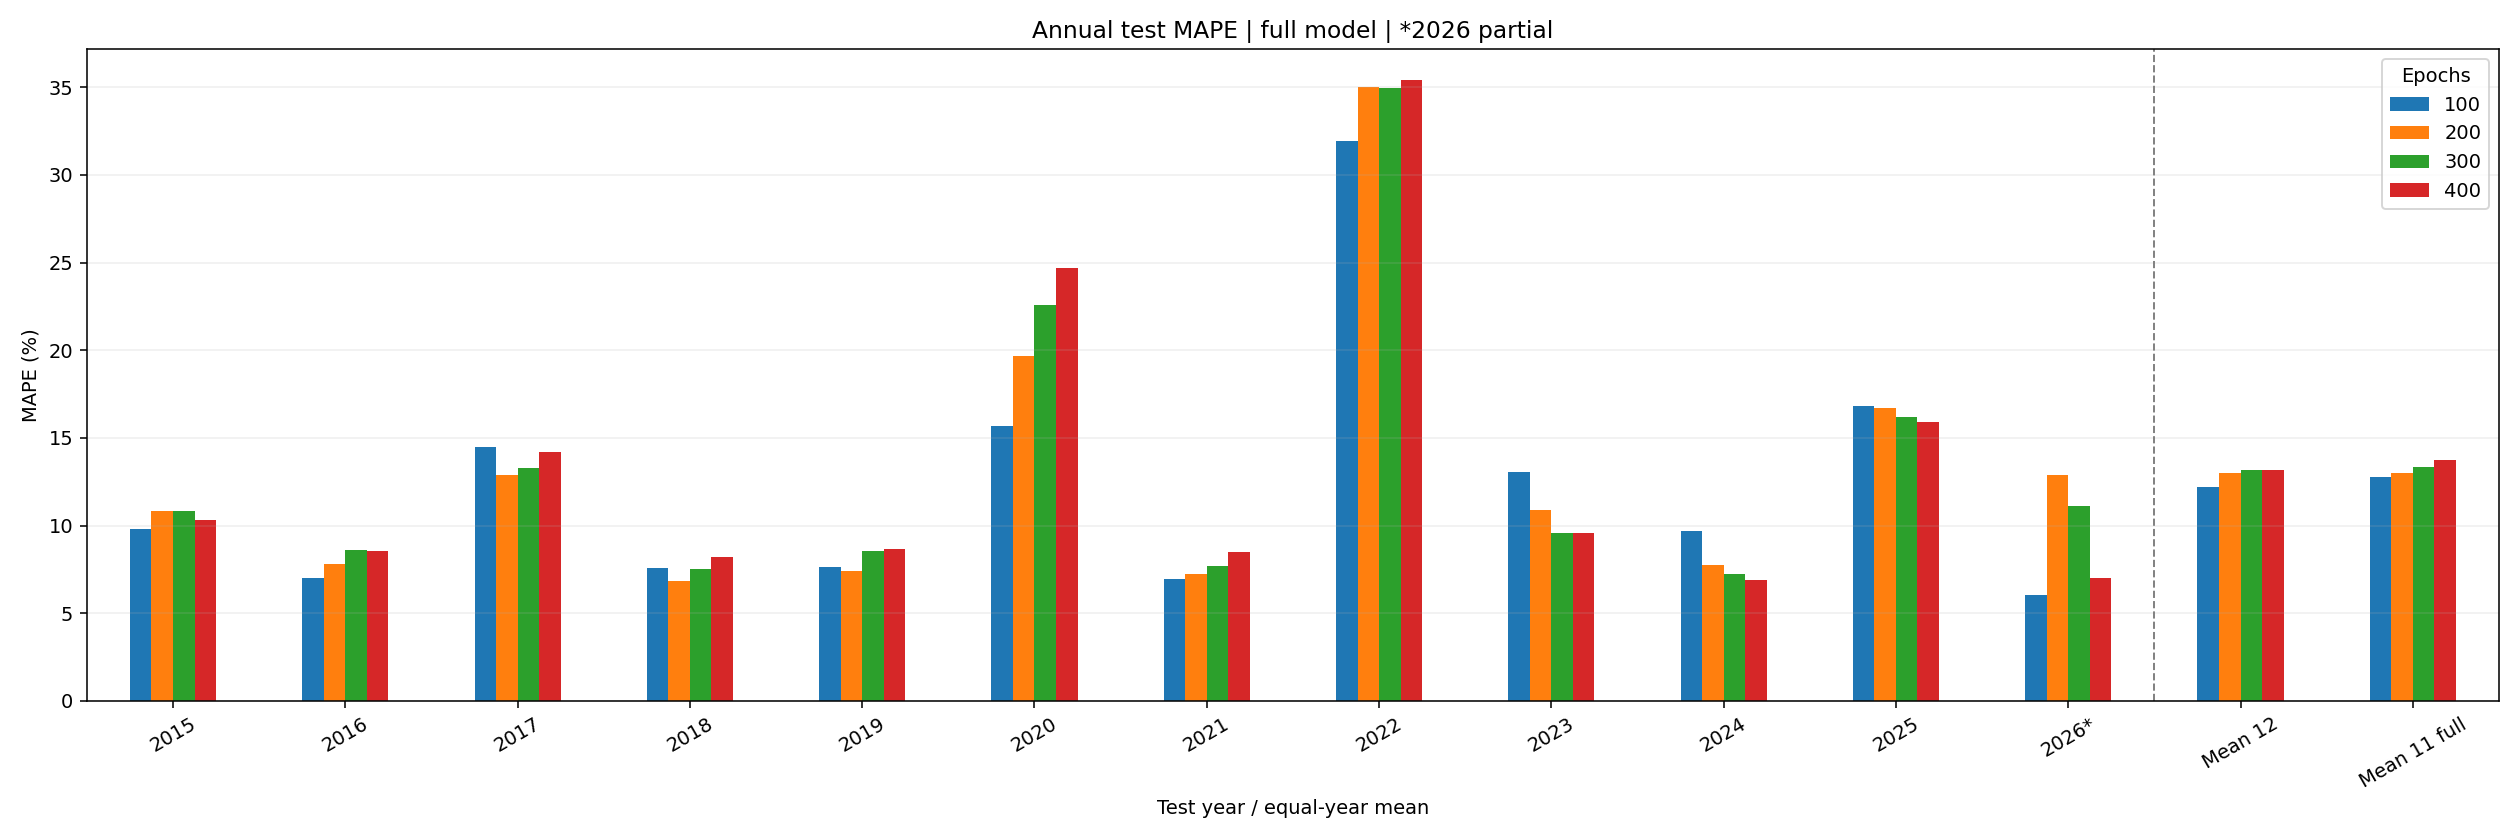

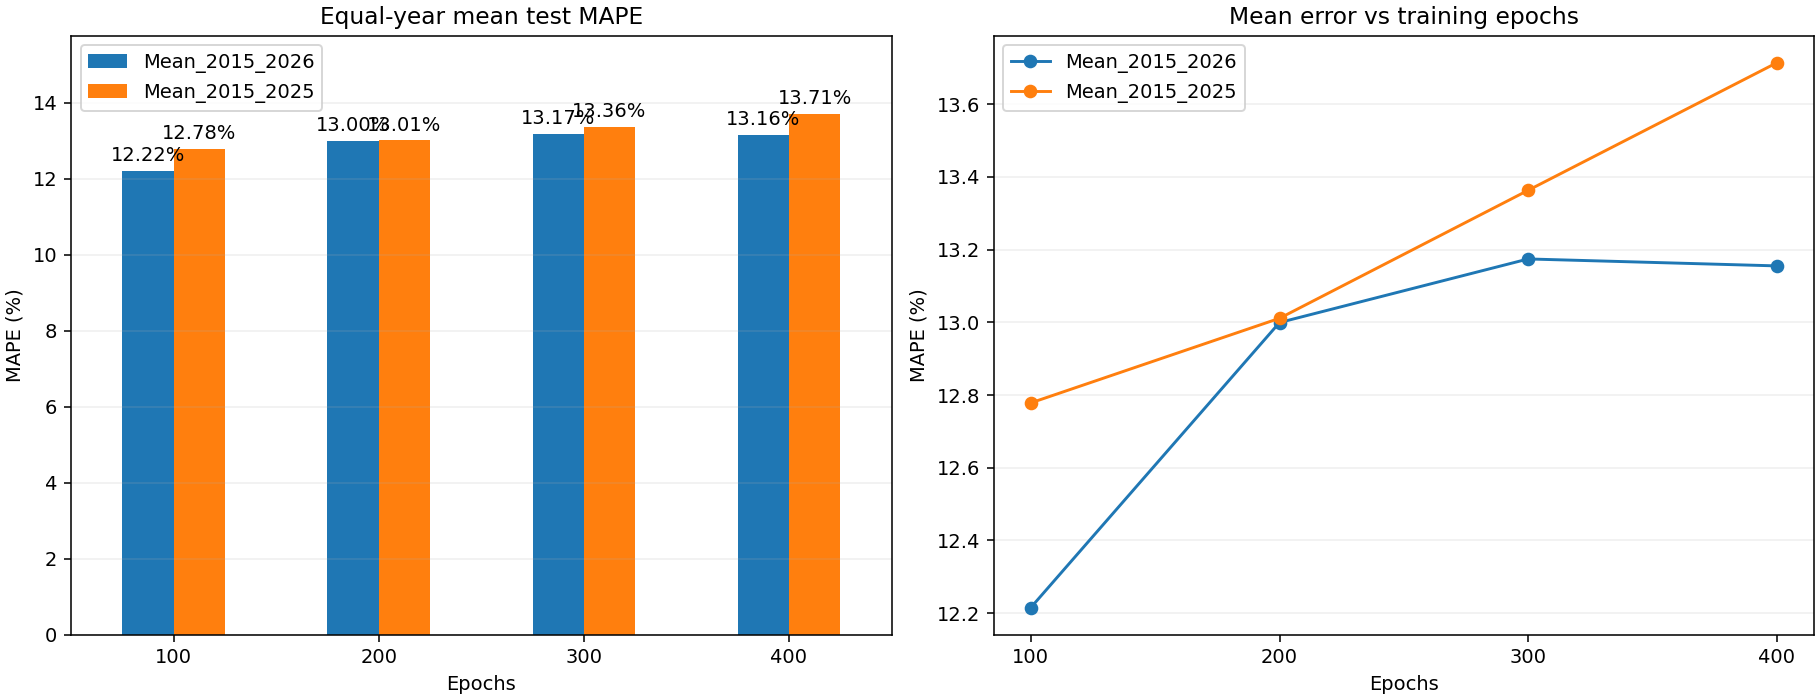

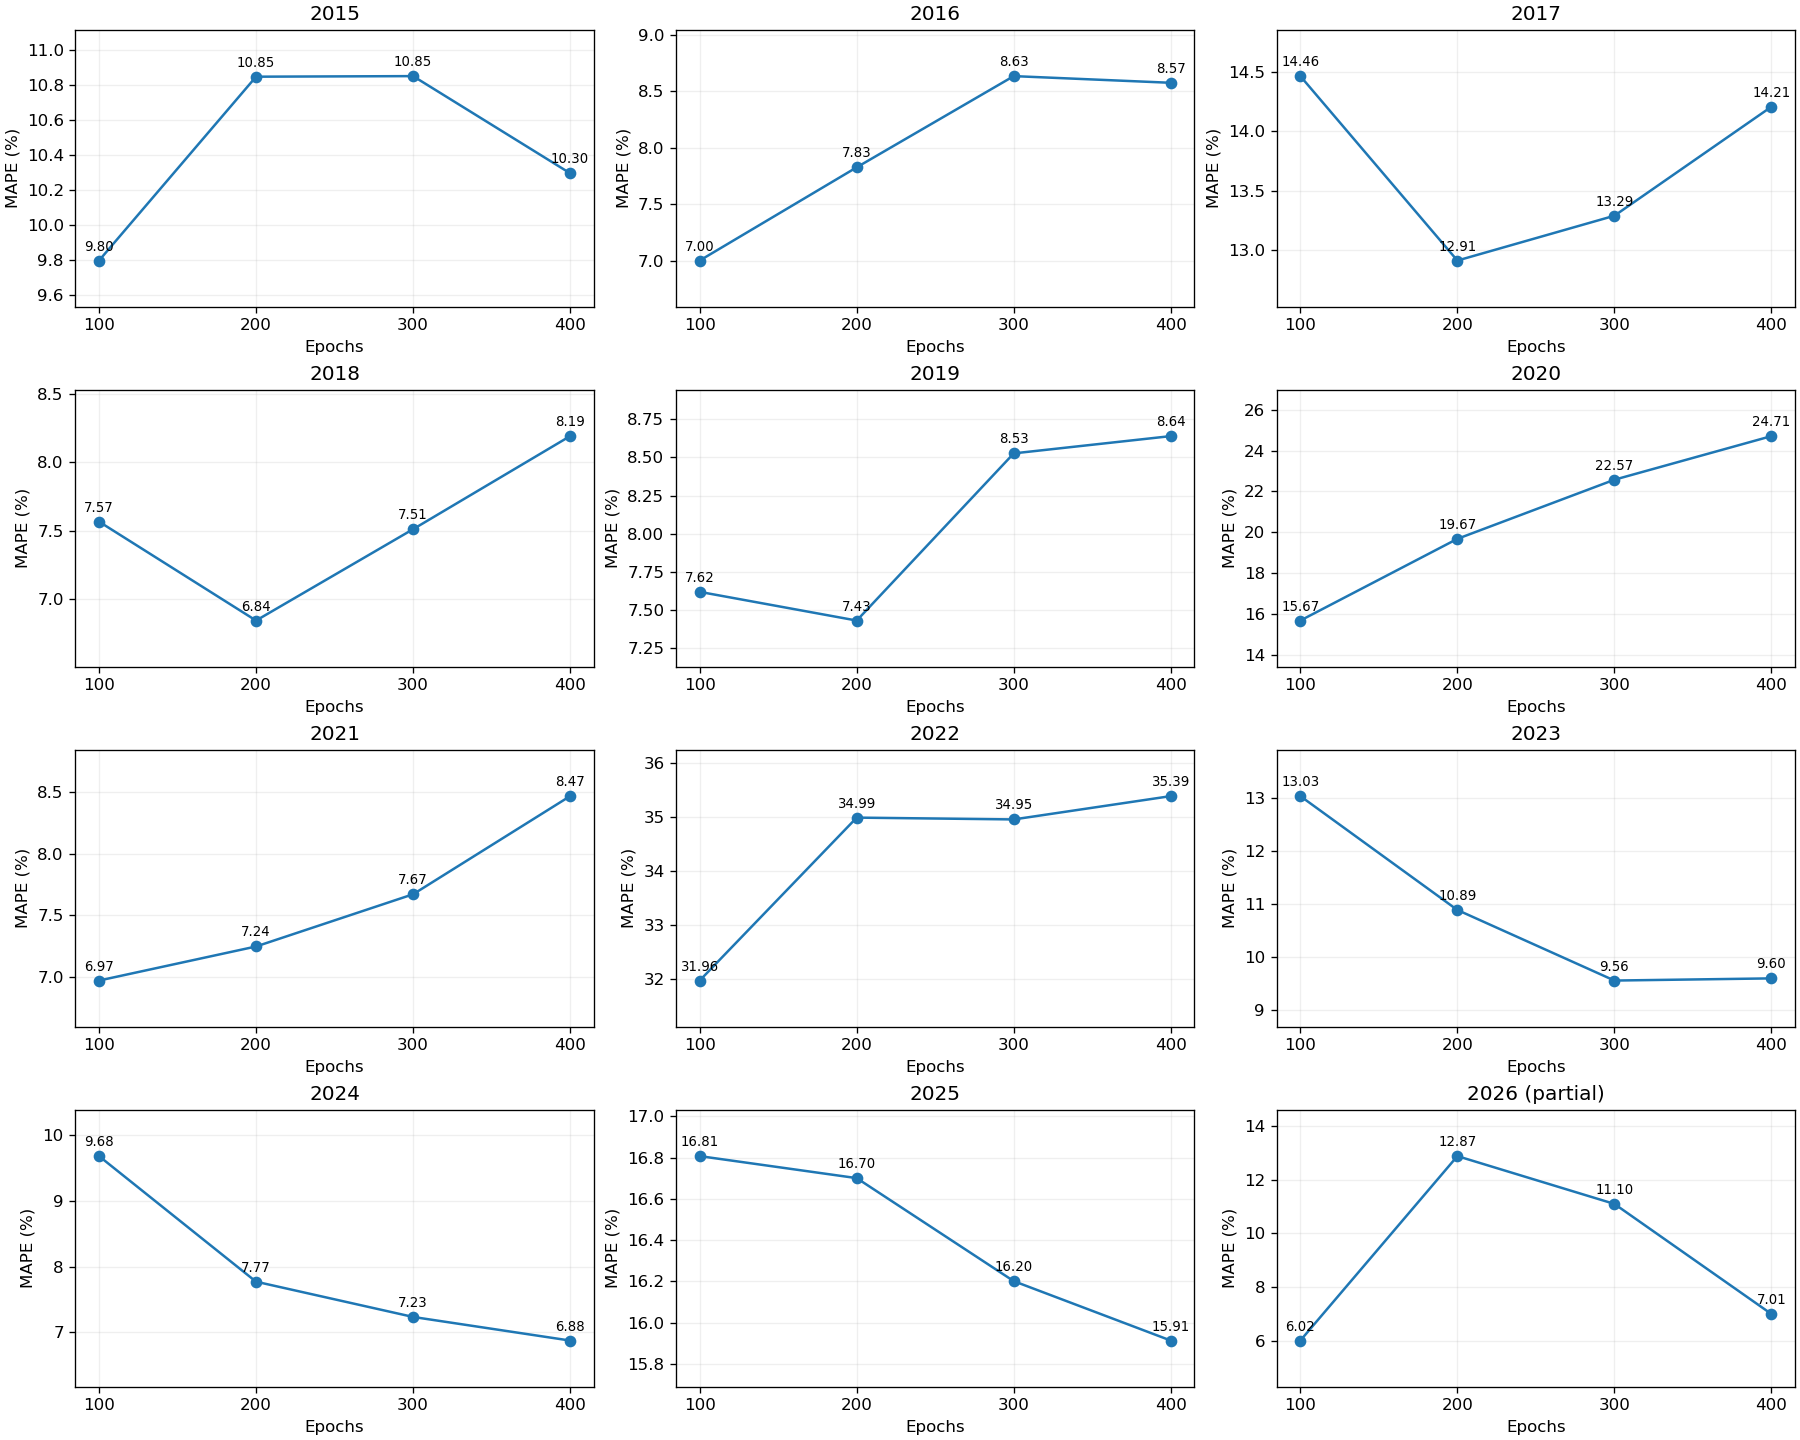

In [3]:
chart=annual.copy();chart.index=[str(y)+('*' if y==2026 else '') for y in chart.index]
chart.loc['Mean 12']=means.loc['Mean_2015_2026'];chart.loc['Mean 11 full']=means.loc['Mean_2015_2025']
ax=chart.plot.bar(figsize=(18,6),rot=30)
ax.set(title='Annual test MAPE | full model | *2026 partial',xlabel='Test year / equal-year mean',ylabel='MAPE (%)')
ax.axvline(11.5,color='gray',ls='--',lw=1);ax.grid(axis='y',alpha=.2)
ax.legend(title='Epochs');plt.tight_layout();plt.savefig(OUT/'annual_mape_bar.png',dpi=140);plt.show()
fig,axes=plt.subplots(1,2,figsize=(13,5),constrained_layout=True)
means.T.plot.bar(ax=axes[0],rot=0,color=['tab:blue','tab:orange'])
for container in axes[0].containers:axes[0].bar_label(container,fmt='%.2f%%',padding=3)
axes[0].set(title='Equal-year mean test MAPE',xlabel='Epochs',ylabel='MAPE (%)');axes[0].margins(y=.15)
for name,row in means.iterrows():axes[1].plot(CANDIDATES,row.to_numpy(),marker='o',label=name)
axes[1].set(title='Mean error vs training epochs',xlabel='Epochs',ylabel='MAPE (%)',xticks=CANDIDATES)
axes[1].legend()
for ax in axes:ax.grid(axis='y',alpha=.2)
fig.savefig(OUT/'mean_mape_curve.png',dpi=140);plt.show()
fig,axes=plt.subplots(4,3,figsize=(15,12),constrained_layout=True)
for ax,year in zip(axes.flat,YEARS):
    vals=annual.loc[year];ax.plot(CANDIDATES,vals,marker='o')
    for epoch,value in vals.items():ax.annotate(f'{value:.2f}',(epoch,value),xytext=(0,6),textcoords='offset points',ha='center',fontsize=8)
    ax.set(title=str(year)+(' (partial)' if year==2026 else ''),xlabel='Epochs',ylabel='MAPE (%)',xticks=CANDIDATES)
    ax.margins(y=.25);ax.grid(alpha=.2)
fig.savefig(OUT/'annual_mape_curves.png',dpi=120);plt.show()


## 100—400轮本次结论

100/200/300/400轮的2015—2026年度等权平均MAPE分别为 **12.2155%、12.9996%、13.1745%、13.1554%**；完整2015—2025分别为12.7785%、13.0113%、13.3634%、13.7143%。两种汇总都以100轮最低。12年平均并未出现先降后升：100至300上升，400略回落。

各年四个候选中最低轮数：100轮6年（2015、2016、2020、2021、2022、2026）；200轮3年（2017、2018、2019）；300轮1年（2023）；400轮2年（2024、2025）。2017、2018、2019、2023四年出现四个采样点严格先降后升，其余年份形状不同。

2026分别为6.0224%、12.8715%、11.0960%、7.0076%，说明测试误差并不随训练次数平滑单调变化。100轮的所有年度结果与此前全模型实验一致，400轮与上一节逐年一致。

结果仅支持100轮在本次四候选和seed42下年度平均最优，不代表各年最佳，也不证明100轮在其他候选、初始化或未来时期仍最好。2022保留，2026为截至7月23日的部分年度。

---

## 结论  
从近年来看,轮数选择400轮最好.  
但是在2020-2022中,训练轮数的增多会急剧增加误差.这时候,反而是较少的训练轮数具有更大的优势.  
也就是说,选择100轮,或者选择400/600轮,取决于特殊的年份.但是为什么20-22年的表现会如此差呢?这便是接下来要探究的方向.

或者,对于20-22年的情况,我们采用验证集测试,看看哪个平均表现最好就选用它.这样能够解决自动选择训练轮数的问题吗?